In [1]:
from relbench.datasets import get_dataset, get_dataset_names, register_dataset

In [2]:
import os
import pandas as pd
import numpy as np
from relbench.base import Database, Dataset, Table

class TransactionalDataset(Dataset):
    # Set timestamps or other relevant information if needed
    val_timestamp = pd.Timestamp("2024-01-23")
    test_timestamp = pd.Timestamp("2024-01-30")

    def make_db(self) -> Database:
        # Path to your CSVs folder
        path = os.path.join("D:/Dani/relbench/relbench/burger_data/", "trans")   
        customers = os.path.join(path, "customer_data.csv")
        articles = os.path.join(path, "article_data.csv")
        branches = os.path.join(path, "branch_data.csv")
        transactions = os.path.join(path, "synTrans.csv")



        # Ensure that CSV files exist in the specified path
        if not os.path.exists(customers):
            raise RuntimeError(f"Dataset not found at '{path}'. Please make sure the CSV files are in the correct folder.")

        # Read the CSV data into pandas DataFrames
        customers_df = pd.read_csv(customers)
        articles_df = pd.read_csv(articles)
        branches_df = pd.read_csv(branches)
        transactions_df = pd.read_csv(transactions)
        transactions_df['d_dat'] = pd.to_datetime(transactions_df['d_dat'])
        split_date = pd.to_datetime('2022-01-01')
        transactions_df = transactions_df[transactions_df['d_dat'] >= split_date]
        transactions_df = transactions_df.reset_index(drop=True)
        ################################################################################
        # Check for and handle duplicate primary keys in articles, customers, and branches tables
        ################################################################################

        # Handle duplicates in the articles table
        if articles_df.duplicated(subset=['articles_id']).any():
            print("Duplicates found in the 'articles_id' column. Removing duplicates...")
            articles_df = articles_df.drop_duplicates(subset=['articles_id'], keep='first')

        # Handle duplicates in the customers table
        if customers_df.duplicated(subset=['customers_id']).any():
            print("Duplicates found in the 'customers_id' column. Removing duplicates...")
            customers_df = customers_df.drop_duplicates(subset=['customers_id'], keep='first')

        # Handle duplicates in the branches table
        if branches_df.duplicated(subset=['BranchCode']).any():
            print("Duplicates found in the 'BranchCode' column. Removing duplicates...")
            branches_df = branches_df.drop_duplicates(subset=['BranchCode'], keep='first')

        ################################################################################
        # Clean and process the data (drop unnecessary columns, handle missing data)
        ################################################################################
        # Drop unnecessary columns
        transactions_df.drop(columns=["factor_id"], inplace=True)
        transactions_df.drop(columns=["date"], inplace=True)
        transactions_df.drop(columns=["art_name"], inplace=True)
        transactions_df.drop(columns=["price_item"], inplace=True)
        transactions_df.drop(columns=["BranchName"], inplace=True)
        transactions_df.drop(columns=["FoodTypeName"], inplace=True)
        transactions_df.drop(columns=["FoodType"], inplace=True)
        transactions_df.drop(columns=["Maliat"], inplace=True)       
        transactions_df.drop(columns=["Service"], inplace=True)            
        transactions_df.drop(columns=["group_id"], inplace=True)            
        # articles_df.drop(columns=["Item Barcode", "External Item Number"], inplace=True)

        transactions_df['Sales channel'] = pd.factorize(transactions_df['Sales channel'])[0]

        # Encoding Payment channel column
        # transactions_df['week'] = pd.factorize(transactions_df['week'])[0]


        # Replace any missing or invalid values
        # transactions_df["salesTime"] = transactions_df["salesTime"].replace(r"^\\N$", "00:00:00", regex=True)
        transactions_df = transactions_df.replace(r"^\\N$", np.nan, regex=True)

        # Combine date and time into a single 'datetime' column
        # transactions_df['datetime'] = pd.to_datetime(transactions_df['d_dat'] + ' ' + transactions_df['salesTime'])
        # transactions_df.drop(columns=["d_dat"], inplace=True)        
        # Convert date column to pd.Timestamp
        # transactions_df["datetime"] = pd.to_datetime(transactions_df["datetime"])

        transactions_df["datetime"] = pd.to_datetime(
        transactions_df["d_dat"], format="%Y-%m-%d"
        )
        transactions_df.drop(columns=["d_dat"], inplace=True)          
        # Convert other fields if necessary
        transactions_df['price_purchase'] = pd.to_numeric(transactions_df['price_purchase'], errors='coerce')
        transactions_df['takhfif'] = pd.to_numeric(transactions_df['takhfif'], errors='coerce')
        transactions_df['Quantity'] = pd.to_numeric(transactions_df['Quantity'], errors='coerce')

        ################################################################################
        # Now we define the table structure and relationships.
        ################################################################################

        tables = {}

        # Articles table
        tables["article"] = Table(
            df=pd.DataFrame(articles_df),
            fkey_col_to_pkey_table={},
            pkey_col="articles_id",
            time_col=None,
        )

        # Customers table
        tables["customer"] = Table(
            df=pd.DataFrame(customers_df),
            fkey_col_to_pkey_table={},
            pkey_col="customers_id",
            time_col=None,
        )

        # Branches table (renamed from "branche" to "branches")
        tables["branches"] = Table(
            df=pd.DataFrame(branches_df),
            fkey_col_to_pkey_table={},
            pkey_col="BranchCode",
            time_col=None,
        )

        # Transactions table
        tables["transactions"] = Table(
            df=pd.DataFrame(transactions_df),
            fkey_col_to_pkey_table={
                "articles_id": "article",    # Foreign key to articles
                "customers_id": "customer",  # Foreign key to customers
                "BranchCode": "branches",    # Foreign key to branches
            },
            pkey_col=None,
            time_col="datetime",  # Use the combined datetime column for time-based operations
        )

        return Database(tables)


In [357]:
import os
import pandas as pd
import numpy as np
from relbench.base import Database, Dataset, Table

class TransactionalDataset(Dataset):
    # # Set timestamps or other relevant information if needed
    # val_timestamp = pd.Timestamp("2024-11-17")
    # test_timestamp = pd.Timestamp("2024-12-18")
    # Set timestamps or other relevant information if needed
    val_timestamp = pd.Timestamp("2025-01-3")
    test_timestamp = pd.Timestamp("2025-01-11")
    def make_db(self) -> Database:
        # Path to your CSVs folder
        path = os.path.join("D:/Dani/relbench/relbench/burger_data/", "dorsa")   

        customers = os.path.join(path, "customer_data.csv")
        articles = os.path.join(path, "article_data.csv")
        branches = os.path.join(path, "branch_data.csv")
        transactions = os.path.join(path, "transaction_data.csv")


        # Ensure that CSV files exist in the specified path
        if not os.path.exists(customers):
            raise RuntimeError(f"Dataset not found at '{path}'. Please make sure the CSV files are in the correct folder.")

        # Read the CSV data into pandas DataFrames
        customers_df = pd.read_csv(customers)
        articles_df = pd.read_csv(articles)
        branches_df = pd.read_csv(branches)
        transactions_df = pd.read_csv(transactions)
        transactions_df['d_dat'] = pd.to_datetime(transactions_df['Datetime'])
        transactions_df.drop(columns=["Datetime"], inplace=True)  
        # split_date = pd.to_datetime('2022-01-01')
        # transactions_df = transactions_df[transactions_df['d_dat'] >= split_date]
        transactions_df = transactions_df.reset_index(drop=True)
        ################################################################################
        # Check for and handle duplicate primary keys in articles, customers, and branches tables
        ################################################################################
        customers_df['customers_id'] = customers_df['Customer ID']
        customers_df.drop(columns=["Customer ID"], inplace=True)

        articles_df['articles_id'] = articles_df["Article ID"]
        articles_df.drop(columns=["Article ID"], inplace=True)

        transactions_df['articles_id'] = transactions_df["Article ID"]
        transactions_df.drop(columns=["Article ID"], inplace=True)

        transactions_df['customers_id'] = transactions_df['Customer ID']
        transactions_df.drop(columns=["Customer ID"], inplace=True)

        transactions_df['BranchCode'] = transactions_df['Branch ID']
        transactions_df.drop(columns=["Branch ID"], inplace=True)

        branches_df['BranchCode'] = branches_df['Branch ID']
        branches_df.drop(columns=["Branch ID"], inplace=True)        
        # Handle duplicates in the articles table
        if articles_df.duplicated(subset=['articles_id']).any():
            print("Duplicates found in the 'articles_id' column. Removing duplicates...")
            articles_df = articles_df.drop_duplicates(subset=['articles_id'], keep='first')

        # Handle duplicates in the customers table
        if customers_df.duplicated(subset=['customers_id']).any():
            print("Duplicates found in the 'customers_id' column. Removing duplicates...")
            customers_df = customers_df.drop_duplicates(subset=['customers_id'], keep='first')

        # Handle duplicates in the branches table
        if branches_df.duplicated(subset=['BranchCode']).any():
            print("Duplicates found in the 'BranchCode' column. Removing duplicates...")
            branches_df = branches_df.drop_duplicates(subset=['BranchCode'], keep='first')

        ################################################################################
        # Clean and process the data (drop unnecessary columns, handle missing data)
        ################################################################################
        # Drop unnecessary columns
        
        transactions_df.drop(columns=["Document Barcode"], inplace=True)
        transactions_df.drop(columns=["Net Sales"], inplace=True)
        # transactions_df.drop(columns=["art_name"], inplace=True)
        # transactions_df.drop(columns=["price_item"], inplace=True)
        # transactions_df.drop(columns=["BranchName"], inplace=True)
        # transactions_df.drop(columns=["FoodTypeName"], inplace=True)
        # transactions_df.drop(columns=["FoodType"], inplace=True)
        # transactions_df.drop(columns=["Maliat"], inplace=True)       
        # transactions_df.drop(columns=["Service"], inplace=True)            
        # transactions_df.drop(columns=["group_id"], inplace=True)            
        # articles_df.drop(columns=["Item Barcode", "External Item Number"], inplace=True)

        # transactions_df['Sales channel'] = pd.factorize(transactions_df['Sales channel'])[0]

        # Encoding Payment channel column
        # transactions_df['week'] = pd.factorize(transactions_df['week'])[0]


        # Replace any missing or invalid values
        # transactions_df["salesTime"] = transactions_df["salesTime"].replace(r"^\\N$", "00:00:00", regex=True)
        transactions_df = transactions_df.replace(r"^\\N$", np.nan, regex=True)

        # Combine date and time into a single 'datetime' column
        # transactions_df['datetime'] = pd.to_datetime(transactions_df['d_dat'] + ' ' + transactions_df['salesTime'])
        # transactions_df.drop(columns=["d_dat"], inplace=True)        
        # Convert date column to pd.Timestamp
        # transactions_df["datetime"] = pd.to_datetime(transactions_df["datetime"])

        transactions_df["datetime"] = pd.to_datetime(
        transactions_df["d_dat"], format="%Y-%m-%d"
        )
        transactions_df.drop(columns=["d_dat"], inplace=True)          
        # Convert other fields if necessary
        # transactions_df['price_purchase'] = pd.to_numeric(transactions_df['price_purchase'], errors='coerce')
        # transactions_df['takhfif'] = pd.to_numeric(transactions_df['takhfif'], errors='coerce')
        # transactions_df['Quantity'] = pd.to_numeric(transactions_df['Quantity'], errors='coerce')

        ################################################################################
        # Now we define the table structure and relationships.
        ################################################################################

        tables = {}

        # Articles table
        tables["article"] = Table(
            df=pd.DataFrame(articles_df),
            fkey_col_to_pkey_table={},
            pkey_col="articles_id",
            time_col=None,
        )

        # Customers table
        tables["customer"] = Table(
            df=pd.DataFrame(customers_df),
            fkey_col_to_pkey_table={},
            pkey_col="customers_id",
            time_col=None,
        )

        # Branches table (renamed from "branche" to "branches")
        tables["branches"] = Table(
            df=pd.DataFrame(branches_df),
            fkey_col_to_pkey_table={},
            pkey_col="BranchCode",
            time_col=None,
        )

        # Transactions table
        tables["transactions"] = Table(
            df=pd.DataFrame(transactions_df),
            fkey_col_to_pkey_table={
                "articles_id": "article",    # Foreign key to articles
                "customers_id": "customer",  # Foreign key to customers
                "BranchCode": "branches",    # Foreign key to branches
            },
            pkey_col=None,
            time_col="datetime",  # Use the combined datetime column for time-based operations
        )

        return Database(tables)


In [3]:
import os
import pandas as pd
import numpy as np
from relbench.base import Database, Dataset, Table

class TransactionalDataset(Dataset):
    # Set timestamps or other relevant information if needed
    # val_timestamp = pd.Timestamp("2024-11-17")
    # test_timestamp = pd.Timestamp("2024-12-18")
    val_timestamp = pd.Timestamp("2025-01-3")
    test_timestamp = pd.Timestamp("2025-01-11")
    def make_db(self) -> Database:
        # Path to your CSVs folder
        path = os.path.join("D:/Dani/relbench/relbench/burger_data/dorsa/", "new")   

        customers = os.path.join(path, "customer_data.csv")
        articles = os.path.join(path, "article_data.csv")
        branches = os.path.join(path, "branch_data.csv")
        transactions = os.path.join(path, "transaction_data.csv")

        # Ensure that CSV files exist in the specified path
        if not os.path.exists(customers):
            raise RuntimeError(f"Dataset not found at '{path}'. Please make sure the CSV files are in the correct folder.")

        # Read the CSV data into pandas DataFrames
        customers_df = pd.read_csv(customers)
        articles_df = pd.read_csv(articles)
        branches_df = pd.read_csv(branches)
        transactions_df = pd.read_csv(transactions)
        transactions_df['d_dat'] = pd.to_datetime(transactions_df['Datetime'])
        transactions_df.drop(columns=["Datetime"], inplace=True)  
        transactions_df = transactions_df.reset_index(drop=True)
        
        ################################################################################
        # Check for and handle duplicate primary keys in articles, customers, and branches tables
        ################################################################################
        # customers_df['customers_id'] = customers_df['Customer ID']
        # customers_df.drop(columns=["Customer ID"], inplace=True)

        # articles_df['articles_id'] = articles_df["Article ID"]
        # articles_df.drop(columns=["Article ID"], inplace=True)

        # transactions_df['articles_id'] = transactions_df["Article ID"]
        # transactions_df.drop(columns=["Article ID"], inplace=True)

        # transactions_df['customers_id'] = transactions_df['Customer ID']
        # transactions_df.drop(columns=["Customer ID"], inplace=True)

        # transactions_df['BranchCode'] = transactions_df['Branch ID']
        # transactions_df.drop(columns=["Branch ID"], inplace=True)

        # branches_df['BranchCode'] = branches_df['Branch ID']
        # branches_df.drop(columns=["Branch ID"], inplace=True)        

        # Handle duplicates in the articles table
        articles_df = articles_df.drop_duplicates(subset=['articles_id'], keep='first')
        
        # Handle duplicates in the customers table
        customers_df = customers_df.drop_duplicates(subset=['customers_id'], keep='first')
        
        # Handle duplicates in the branches table
        branches_df = branches_df.drop_duplicates(subset=['BranchCode'], keep='first')
        
        ################################################################################
        # Filter customers with 3 or more transactions
        ################################################################################
        customer_transaction_counts = transactions_df['customers_id'].value_counts()
        valid_customers = customer_transaction_counts[customer_transaction_counts >= 3].index
        transactions_df = transactions_df[transactions_df['customers_id'].isin(valid_customers)]
        customers_df = customers_df[customers_df['customers_id'].isin(valid_customers)]
        
        ################################################################################
        # Clean and process the data (drop unnecessary columns, handle missing data)
        ################################################################################
        transactions_df.drop(columns=["Document Barcode", "Net Sales",'Net Sales Minus Sales Voucher','Tax','Small Change Discount','Base Total Price', 'Year', 'Month', 'Day', 'Allocated Credit', 'Sales Voucher', 'Gift Voucher', 'Cash Card', 'Special Discount', 'Promotion Discount'], inplace=True)
        transactions_df = transactions_df.replace(r"^\\N$", np.nan, regex=True)

        # Convert date column to pd.Timestamp
        transactions_df["datetime"] = pd.to_datetime(transactions_df["d_dat"], format="%Y-%m-%d")
        transactions_df.drop(columns=["d_dat"], inplace=True)          
        
        ################################################################################
        # Now we define the table structure and relationships.
        ################################################################################
        tables = {}

        # Articles table
        tables["article"] = Table(
            df=pd.DataFrame(articles_df),
            fkey_col_to_pkey_table={},
            pkey_col="articles_id",
            time_col=None,
        )

        # Customers table
        tables["customer"] = Table(
            df=pd.DataFrame(customers_df),
            fkey_col_to_pkey_table={},
            pkey_col="customers_id",
            time_col=None,
        )

        # Branches table
        tables["branches"] = Table(
            df=pd.DataFrame(branches_df),
            fkey_col_to_pkey_table={},
            pkey_col="BranchCode",
            time_col=None,
        )

        # Transactions table
        tables["transactions"] = Table(
            df=pd.DataFrame(transactions_df),
            fkey_col_to_pkey_table={
                "articles_id": "article",    # Foreign key to articles
                "customers_id": "customer",  # Foreign key to customers
                "BranchCode": "branches",    # Foreign key to branches
            },
            pkey_col=None,
            time_col="datetime",  # Use the combined datetime column for time-based operations
        )

        return Database(tables)


In [4]:
transactional_dataset = TransactionalDataset()
db = transactional_dataset.make_db()

In [4]:
table = db.table_dict["transactions"]

In [5]:
db.table_dict["transactions"].df.describe()

,BranchCode,Transaction Serial,customers_id,articles_id,Style Code,Quantity,Sale Total Price,Total Discounts,Discount Percentage,datetime
count,360698.000000,360698.000000,3.606980e+05,360698.000000,360698.00000,360698.000000,3.606980e+05,3.606980e+05,360698.000000,360698
mean,10414.970491,36659.250667,1.028951e+07,42093.038572,2997.25380,1.236741,6.745767e+07,1.948162e+07,3.623573,2022-12-16 23:26:04.274049024
min,10001.000000,100.000000,1.000000e+07,1048.000000,99.00000,1.000000,1.000000e+00,-1.485000e+08,-2284.620000,2021-03-21 11:15:15
25%,10131.000000,8634.000000,1.017943e+07,38036.000000,2374.00000,1.000000,1.246789e+07,2.000000e+00,0.000000,2021-12-22 11:26:21
50%,10317.000000,22164.000000,1.032058e+07,44168.000000,3037.00000,1.000000,3.005909e+07,4.220448e+06,0.000000,2022-10-25 17:04:12
75%,10642.000000,57178.000000,1.040394e+07,49766.000000,3670.00000,1.000000,5.742202e+07,1.730952e+07,0.000000,2024-01-18 19:47:57.500000
max,13827.000000,146172.000000,1.048279e+07,63063.000000,5367.00000,14390.000000,2.862386e+10,2.930959e+10,100.000000,2025-01-19 23:54:03
std,312.068203,37009.869494,1.333624e+05,11605.668984,932.19883,36.573872,2.430170e+08,9.498931e+07,12.731389,NaN


In [81]:
b = db.table_dict["article"]

In [82]:
b.df.describe()

,articles_id,Base Unit Price,Style Code,Collection Code,Idea Code,Initial Pattern Code,Year
count,7440.0,7.440000e+03,7440.000000,7440.000000,7440.000000,7440.000000,7440.000000
mean,3719.5,4.235657e+07,502.110484,7.325134,0.012231,176.222849,1379.825403
std,2147.887334,5.906584e+07,300.053261,14.488141,0.152007,99.793045,165.905661
min,0.0,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1859.75,1.087200e+07,253.750000,0.000000,0.000000,78.000000,1398.000000
50%,3719.5,2.600000e+07,443.000000,0.000000,0.000000,198.000000,1400.000000
75%,5579.25,5.459023e+07,733.250000,0.000000,0.000000,277.000000,1401.000000
max,7439.0,2.419000e+09,1122.000000,57.000000,3.000000,277.000000,1403.000000


In [83]:
c = db.table_dict["customer"]

In [452]:
c.df.columns

Index(['Customer Category', 'customers_id', 'Customer Process', 'City'], dtype='object')

In [453]:
d = db.table_dict["branches"]

In [454]:
d.df.columns

Index(['BranchCode', 'Branch Name', 'City'], dtype='object')

In [100]:
table.df.iloc[table.df["datetime"].idxmax()]

Transaction Type                         فاکتور فروش
Transaction Serial                           24075.0
Time                                        23:54:03
Quantity                                           5
Base Total Price                                 0.0
Sale Total Price                                 0.0
Year                                          1403.0
Month                                           10.0
Day                                             30.0
Season                                        زمستان
Allocated Credit                                 0.0
Sales Voucher                                    0.0
Gift Voucher                                     0.0
Cash Card                                        0.0
Special Discount                                 0.0
Promotion Discount                               0.0
Small Change Discount                            0.0
Tax                                              0.0
Total Discounts                               

In [101]:
table.df.iloc[table.df["datetime"].idxmin()]

Transaction Type                         فاکتور فروش
Transaction Serial                            6445.0
Time                                        11:15:15
Quantity                                          10
Base Total Price                                10.0
Sale Total Price                                10.0
Year                                          1400.0
Month                                            1.0
Day                                              1.0
Season                                          بهار
Allocated Credit                                 1.0
Sales Voucher                                    0.0
Gift Voucher                                     0.0
Cash Card                                        0.0
Special Discount                                 0.0
Promotion Discount                               0.0
Small Change Discount                            0.0
Tax                                              1.0
Total Discounts                               

In [5]:
register_dataset("Dorsa-aras14", TransactionalDataset)
get_dataset_names()

['rel-amazon',
 'rel-avito',
 'rel-event',
 'rel-f1',
 'rel-hm',
 'rel-stack',
 'rel-trial',
 'Dorsa-aras14']

In [6]:
hyper_dataset = get_dataset("Dorsa-aras14")
hyper_dataset

TransactionalDataset()

In [7]:
hyper_dataset.val_timestamp, hyper_dataset.test_timestamp

(Timestamp('2025-01-03 00:00:00'), Timestamp('2025-01-11 00:00:00'))

In [8]:
import relbench

relbench.__version__

'1.1.0'

In [9]:
import duckdb
import pandas as pd
from relbench.tasks import get_task, get_task_names, register_task
from relbench.base import Database, EntityTask, RecommendationTask, Table, TaskType
from relbench.metrics import (
    accuracy,
    average_precision,
    f1,
    link_prediction_map,
    link_prediction_precision,
    link_prediction_recall,
    mae,
    r2,
    rmse,
    roc_auc,
)
from metrics import link_prediction_top
class UserItemPurchaseTask(RecommendationTask):
    r"""Predict the list of articles each customer will purchase in the next seven
    days."""

    task_type = TaskType.LINK_PREDICTION
    src_entity_col = "customer_id"
    src_entity_table = "customer"
    dst_entity_col = "article_id"
    dst_entity_table = "article"
    time_col = "timestamp"
    timedelta = pd.Timedelta(days=7)
    metrics = [link_prediction_precision, link_prediction_recall, link_prediction_map, link_prediction_top]
    eval_k = 12

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        customer = db.table_dict["customer"].df
        transactions = db.table_dict["transactions"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                t.timestamp,
                transactions.customer_id,
                LIST(DISTINCT transactions.article_id) AS article_id
            FROM
                timestamp_df t
            LEFT JOIN
                transactions
            ON
                transactions.t_dat > t.timestamp AND
                transactions.t_dat <= t.timestamp + INTERVAL '{self.timedelta} days'
            GROUP BY
                t.timestamp,
                transactions.customer_id
            """
        ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={
                self.src_entity_col: self.src_entity_table,
                self.dst_entity_col: self.dst_entity_table,
            },
            pkey_col=None,
            time_col=self.time_col,
        )

# Task 1: Predict articles each customer will purchase in the next 7 days
# class CustomerArticlePurchaseTask(RecommendationTask):
#     r"""Predict the list of articles each customer will purchase in the next seven days."""
    
#     task_type = TaskType.LINK_PREDICTION
#     src_entity_col = "customers_id"
#     src_entity_table = "customer"
#     dst_entity_col = "articles_id"
#     dst_entity_table = "article"
#     time_col = "timestamp"
#     timedelta = pd.Timedelta(days=7)
#     metrics = [link_prediction_precision, link_prediction_recall, link_prediction_map, link_prediction_top]
#     eval_k = 4

#     def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
#         transactions = db.table_dict["transactions"].df
#         timestamp_df = pd.DataFrame({"timestamp": timestamps})

#         df = duckdb.sql(
#             f"""
#             SELECT
#                 t.timestamp,
#                 transactions.customers_id,
#                 LIST(DISTINCT transactions.articles_id) AS articles_id
#             FROM
#                 timestamp_df t
#             LEFT JOIN
#                 transactions
#             ON
#                 transactions.datetime > t.timestamp AND
#                 transactions.datetime <= t.timestamp + INTERVAL '{self.timedelta.days} days'
#             GROUP BY
#                 t.timestamp,
#                 transactions.customers_id
#             """
#         ).df()

#         return Table(
#             df=df,
#             fkey_col_to_pkey_table={
#                 self.src_entity_col: self.src_entity_table,
#                 self.dst_entity_col: self.dst_entity_table,
#             },
#             pkey_col=None,
#             time_col=self.time_col,
#         )


# Task 2: Predict customer churn (no purchases in the next week)
class CustomerChurnTask(EntityTask):
    r"""Predict the churn for a customer (no transactions)  in the next week."""

    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = "customers_id"
    entity_table = "customer"
    time_col = "timestamp"
    target_col = "churn"
    timedelta = pd.Timedelta(days=7)
    timedelta1 = pd.Timedelta(days=7)
    metrics = [average_precision, accuracy, f1, roc_auc]
    # metrics = [average_precision, accuracy, f1]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        customer = db.table_dict["customer"].df
        transactions = db.table_dict["transactions"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                timestamp,
                customers_id,
                CAST(
                    NOT EXISTS (
                        SELECT 1
                        FROM transactions
                        WHERE
                            transactions.customers_id = customer.customers_id AND
                            transactions.datetime > timestamp AND
                            transactions.datetime <= timestamp + INTERVAL '{self.timedelta}'
                    ) AS INTEGER
                ) AS churn
            FROM
                timestamp_df,
                customer
            WHERE
                EXISTS (
                    SELECT 1
                    FROM transactions
                    WHERE
                        transactions.customers_id = customer.customers_id AND
                        transactions.datetime > timestamp - INTERVAL '{self.timedelta1}' AND
                        transactions.datetime <= timestamp
                )
            """
        ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        ) 
class CustomerChurnTask1(EntityTask):
    r"""Predict the churn for a customer (no transactions) in the next week."""

    task_type = TaskType.BINARY_CLASSIFICATION
    entity_col = "customers_id"
    entity_table = "customer"
    time_col = "timestamp"
    target_col = "churn"
    timedelta = pd.Timedelta(days=7)  # Next 7 days
    timedelta1 = pd.Timedelta(days=7)  # Last 180 days (for activity check)
    metrics = [average_precision, accuracy, f1, roc_auc]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        customer = db.table_dict["customer"].df
        transactions = db.table_dict["transactions"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                timestamp,
                customers_id,
                CAST(
                    EXISTS (
                        SELECT 1
                        FROM transactions
                        WHERE
                            transactions.customers_id = customer.customers_id AND
                            transactions.datetime > timestamp AND
                            transactions.datetime <= timestamp + INTERVAL '{self.timedelta}'
                    ) AS INTEGER
                ) AS churn
            FROM
                timestamp_df,
                customer
            WHERE
                EXISTS (
                    SELECT 1
                    FROM transactions
                    WHERE
                        transactions.customers_id = customer.customers_id AND
                        transactions.datetime > timestamp - INTERVAL '{self.timedelta1}' AND
                        transactions.datetime <= timestamp
                )
                """
                ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        )
# Task 3: Predict article sales in the next 7 days
class ArticleSalesTask(EntityTask):
    r"""Predict the total sales for an article (sum of `price_purchase`) in the next 7 days."""
    
    task_type = TaskType.REGRESSION
    entity_col = "articles_id"
    entity_table = "article"
    time_col = "datetime"
    target_col = "sales"
    timedelta = pd.Timedelta(days=7)
    metrics = [r2, mae, rmse]

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        transactions = db.table_dict["transactions"].df
        articles = db.table_dict["article"].df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})

        df = duckdb.sql(
            f"""
            SELECT
                t.timestamp,
                a.articles_id,
                COALESCE(SUM(transactions.price_purchase), 0) AS sales
            FROM
                timestamp_df t,
                article a
            LEFT JOIN
                transactions
            ON
                transactions.articles_id = a.articles_id AND
                transactions.datetime > t.timestamp AND
                transactions.datetime <= t.timestamp + INTERVAL '{self.timedelta.days} days'
            GROUP BY
                t.timestamp,
                a.articles_id
            """
        ).df()

        return Table(
            df=df,
            fkey_col_to_pkey_table={self.entity_col: self.entity_table},
            pkey_col=None,
            time_col=self.time_col,
        )



In [10]:
aras_churn_task = CustomerChurnTask1(hyper_dataset, cache_dir="D:/Dani/relbench/cache/burger_ara34s3ی3245516644434433433356rf3d3s3df2")
aras_churn_task

CustomerChurnTask1(dataset=TransactionalDataset())

In [11]:
register_task("Dorsa-aras14", "aras_churn_task", CustomerChurnTask1)
get_task_names("Dorsa-aras14")

['aras_churn_task']

In [12]:
import numpy as np

from torch.nn import BCEWithLogitsLoss, L1Loss
from relbench.datasets import get_dataset
from relbench.tasks import get_task

dataset = get_dataset("Dorsa-aras14")
task = get_task("Dorsa-aras14", "aras_churn_task")


train_table = task.get_table("train")
val_table = task.get_table("val")
test_table = task.get_table("test")

out_channels = 1
loss_fn = BCEWithLogitsLoss()
tune_metric = "roc_auc"
higher_is_better = True

In [13]:
train_table

Table(df=
        timestamp  customers_id  churn
0      2021-09-24         54854      0
1      2021-09-17         53754      0
2      2021-09-17         54085      0
3      2021-09-10         53926      1
4      2021-09-10         54772      0
...           ...           ...    ...
188762 2024-09-20          1531      0
188763 2024-09-20          1842      0
188764 2024-09-13           553      0
188765 2024-09-13          1094      0
188766 2024-09-13          1630      1

[188767 rows x 3 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [15]:
val_table

Table(df=
     timestamp  customers_id  churn
0   2025-01-03          1950      0
1   2025-01-03          2528      0
2   2025-01-03          2747      0
3   2025-01-03          2841      0
4   2025-01-03          2855      0
..         ...           ...    ...
668 2025-01-03         44588      1
669 2025-01-03         47632      0
670 2025-01-03         50683      0
671 2025-01-03         52535      0
672 2025-01-03         53848      0

[673 rows x 3 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [17]:
test_table

Table(df=
     timestamp  customers_id
0   2025-01-11           578
1   2025-01-11           962
2   2025-01-11          2821
3   2025-01-11          3366
4   2025-01-11          6941
..         ...           ...
841 2025-01-11         49085
842 2025-01-11         51854
843 2025-01-11         52186
844 2025-01-11         54793
845 2025-01-11         54942

[846 rows x 2 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [18]:
test_data1 = task.get_table("test", mask_input_cols=False)
test_data1

Table(df=
     timestamp  customers_id  churn
0   2025-01-11           578      0
1   2025-01-11           962      0
2   2025-01-11          2821      0
3   2025-01-11          3366      0
4   2025-01-11          6941      0
..         ...           ...    ...
841 2025-01-11         49085      1
842 2025-01-11         51854      0
843 2025-01-11         52186      0
844 2025-01-11         54793      0
845 2025-01-11         54942      0

[846 rows x 3 columns],
  fkey_col_to_pkey_table={'customers_id': 'customer'},
  pkey_col=None,
  time_col=timestamp)

In [19]:
tes1 = test_data1.df

In [20]:
value_counts = tes1['churn'].value_counts()

# Display the result
print(value_counts)

churn
0    719
1    127
Name: count, dtype: int64


## Feature extraction

In [14]:
import os
import math
import numpy as np
from tqdm import tqdm

import torch
import torch_geometric
import torch_frame

# Some book keeping
from torch_geometric.seed import seed_everything

seed_everything(42)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # check that it's cuda if you want it to run in reasonable time!
root_dir = "./data_ARAS"

c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda


In [15]:
from relbench.modeling.utils import get_stype_proposal

db = dataset.get_db()
col_to_stype_dict = get_stype_proposal(db)
col_to_stype_dict

Loading Database object from C:\Users\KN2C\AppData\Local\relbench\relbench\Cache/Dorsa-aras14/db...
Done in 0.21 seconds.


{'article': {'articles_id': <stype.numerical: 'numerical'>,
  'Article Description': <stype.text_embedded: 'text_embedded'>,
  'Base Unit Price': <stype.numerical: 'numerical'>,
  'Style Code': <stype.numerical: 'numerical'>,
  'Style Description': <stype.text_embedded: 'text_embedded'>,
  'Collection Code': <stype.numerical: 'numerical'>,
  'Collection Name': <stype.text_embedded: 'text_embedded'>,
  'Idea Code': <stype.numerical: 'numerical'>,
  'Idea Description': <stype.text_embedded: 'text_embedded'>,
  'Initial Pattern Code': <stype.numerical: 'numerical'>,
  'Initial Pattern Description': <stype.text_embedded: 'text_embedded'>,
  'Product Category': <stype.categorical: 'categorical'>,
  'Product Group': <stype.text_embedded: 'text_embedded'>,
  'Product Subgroup': <stype.text_embedded: 'text_embedded'>,
  'Product Type': <stype.text_embedded: 'text_embedded'>,
  'Material Category': <stype.text_embedded: 'text_embedded'>,
  'Material Type': <stype.text_embedded: 'text_embedded'>

In [58]:
# from relbench.modeling.schema import Stype
from torch_frame import stype
# Modify specific column stype manually
col_to_stype_dict['article']['Style Code'] = stype.categorical  
col_to_stype_dict['article']['Collection Code'] = stype.categorical  
col_to_stype_dict['article']['Idea Code'] = stype.categorical  
col_to_stype_dict['article']['Initial Pattern Code'] = stype.categorical  
 
# col_to_stype_dict['transactions']['Year'] = stype.categorical 
# col_to_stype_dict['transactions']['Month'] = stype.categorical 

# Now you can use col_to_stype_dict in your modeling pipeline
print(col_to_stype_dict)

{'article': {'articles_id': <stype.numerical: 'numerical'>, 'Article Description': <stype.text_embedded: 'text_embedded'>, 'Base Unit Price': <stype.numerical: 'numerical'>, 'Style Code': <stype.categorical: 'categorical'>, 'Style Description': <stype.text_embedded: 'text_embedded'>, 'Collection Code': <stype.categorical: 'categorical'>, 'Collection Name': <stype.text_embedded: 'text_embedded'>, 'Idea Code': <stype.categorical: 'categorical'>, 'Idea Description': <stype.text_embedded: 'text_embedded'>, 'Initial Pattern Code': <stype.categorical: 'categorical'>, 'Initial Pattern Description': <stype.text_embedded: 'text_embedded'>, 'Product Category': <stype.categorical: 'categorical'>, 'Product Group': <stype.text_embedded: 'text_embedded'>, 'Product Subgroup': <stype.text_embedded: 'text_embedded'>, 'Product Type': <stype.text_embedded: 'text_embedded'>, 'Material Category': <stype.text_embedded: 'text_embedded'>, 'Material Type': <stype.text_embedded: 'text_embedded'>, 'Processing': 

In [16]:
from typing import List, Optional
from sentence_transformers import SentenceTransformer
from torch import Tensor
import torch

class HuggingFaceTextEmbedding:
    def __init__(self, model_name: str = "sentence-transformers/all-mpnet-base-v2", 
                 device: Optional[str] = None):
        """
        Initialize the sentence transformer model from Hugging Face.
        :param model_name: The Hugging Face model name for sentence embeddings.
        :param device: The device to use ('cpu' or 'cuda').
        """
        self.model = SentenceTransformer(model_name, device=device)

    def __call__(self, sentences: List[str]) -> Tensor:
        """
        Encode sentences using the Hugging Face sentence-transformer model.
        :param sentences: A list of sentences to encode.
        :return: A PyTorch tensor of embeddings.
        """
        embeddings = self.model.encode(sentences, convert_to_tensor=True)
        return embeddings


In [60]:
from torch_frame.config.text_embedder import TextEmbedderConfig
from relbench.modeling.graph import make_pkey_fkey_graph

# Initialize the text embedder with a Hugging Face model
text_embedder_cfg = TextEmbedderConfig(
    text_embedder=HuggingFaceTextEmbedding(
        model_name="sentence-transformers/all-mpnet-base-v2", device=device
    ), 
    batch_size=64
)

# Generate a graph-based dataset with embeddings
data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict=col_to_stype_dict,  # specified column types
    text_embedder_cfg=text_embedder_cfg,  # using Hugging Face text embeddings
    cache_dir=os.path.join(
        root_dir, f"rel-aras_churn_materialized_cache25"
    ),  # store materialized graph for convenience
)


c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [17]:
from typing import List, Optional
from sentence_transformers import SentenceTransformer
from torch import Tensor
import torch

class BertPersianTextEmbedding:
    def __init__(self, device: Optional[torch.device] = None):
        # Replace the model with a Persian BERT model
        self.model = SentenceTransformer("HooshvareLab/bert-fa-zwnj-base",  # Example Persian BERT model
            device=device,
        )

    def __call__(self, sentences: List[str]) -> Tensor:
        # Encode the sentences using the Persian BERT model and return as a tensor
        return torch.from_numpy(self.model.encode(sentences))


In [18]:
from torch_frame.config.text_embedder import TextEmbedderConfig
from relbench.modeling.graph import make_pkey_fkey_graph

text_embedder_cfg = TextEmbedderConfig(
    text_embedder=BertPersianTextEmbedding(device=device), batch_size=64
)

data, col_stats_dict = make_pkey_fkey_graph(
    db,
    col_to_stype_dict=col_to_stype_dict,  # speficied column types
    text_embedder_cfg=text_embedder_cfg,  # our chosen text encoder
    cache_dir=os.path.join(
        root_dir, f"rel-aras_churn_materialized_cache34"
    ),  # store materialized graph for convenience
)

No sentence-transformers model found with name HooshvareLab/bert-fa-zwnj-base. Creating a new one with mean pooling.
Some weights of BertModel were not initialized from the model checkpoint at HooshvareLab/bert-fa-zwnj-base and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\transformers\tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [19]:
data

HeteroData(
  article={ tf=TensorFrame([18258, 28]) },
  branches={ tf=TensorFrame([75, 2]) },
  customer={ tf=TensorFrame([54955, 3]) },
  transactions={
    tf=TensorFrame([357020, 10]),
    time=[357020],
  },
  (transactions, f2p_articles_id, article)={ edge_index=[2, 357020] },
  (article, rev_f2p_articles_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_customers_id, customer)={ edge_index=[2, 357020] },
  (customer, rev_f2p_customers_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_BranchCode, branches)={ edge_index=[2, 357020] },
  (branches, rev_f2p_BranchCode, transactions)={ edge_index=[2, 357020] }
)

## GNN Implementation

In [20]:
import argparse
import copy
import json
import os
import warnings
from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import torch
import torch.nn.functional as F
# from model import Model
# from text_embedder import GloveTextEmbedding
from torch import Tensor
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from tqdm import tqdm

from relbench.base import Dataset, RecommendationTask, TaskType
from relbench.datasets import get_dataset
from relbench.modeling.graph import get_link_train_table_input, make_pkey_fkey_graph
from relbench.modeling.loader import SparseTensor
from relbench.modeling.utils import get_stype_proposal
from relbench.tasks import get_task

In [ ]:
from relbench.modeling.graph import get_node_train_table_input, make_pkey_fkey_graph
from torch_geometric.loader import NeighborLoader

loader_dict = {}


for split, table in [
    ("train", train_table),
    ("val", val_table),
    ("test", test_table),
]:
    table_input = get_node_train_table_input(
        table=table,
        task=task,
    )
    entity_table = table_input.nodes[0]
    loader_dict[split] = NeighborLoader(
        data,
        num_neighbors=[
            128 for i in range(2)
        ],  # we sample subgraphs of depth 2, 128 neighbors per node.
        time_attr="time",
        input_nodes=table_input.nodes,
        input_time=table_input.time,
        transform=table_input.transform,
        batch_size=512,
        temporal_strategy="uniform", #'recent', 'last'
        shuffle=split == "train",
        num_workers=0,
        persistent_workers=False,
    )

In [ ]:
from torch.nn import BCEWithLogitsLoss
import copy
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType

from relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder


class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = True,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )
        return self.head(x_dict[dst_table])


model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)


# if you try out different RelBench tasks you will need to change these
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
epochs = 10

In [91]:
class Model(torch.nn.Module):
    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        shallow_list: List[NodeType] = [],
        id_awareness: bool = True,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        return_x_dict: bool = False,  # New flag to return x_dict
        x_dict_stage: str = "pre_gnn",  # Stage at which to return x_dict: "pre_gnn" or "post_gnn"
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        if return_x_dict and x_dict_stage == "pre_gnn":
            return x_dict

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        if return_x_dict and x_dict_stage == "post_gnn":
            return x_dict

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
        return_x_dict: bool = False,  # New flag to return x_dict
        x_dict_stage: str = "pre_gnn",  # Stage at which to return x_dict: "pre_gnn" or "post_gnn"
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        if return_x_dict and x_dict_stage == "pre_gnn":
            return x_dict

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        if return_x_dict and x_dict_stage == "post_gnn":
            return x_dict

        return self.head(x_dict[dst_table])

In [92]:
# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

# Use a mini-batch
test_loader_iter = iter(loader_dict["test"])
batch = next(test_loader_iter)
batch = batch.to(device)

# Set num_nodes explicitly to avoid warnings
for node_type in batch.node_types:
    if batch[node_type].num_nodes is None:
        if node_type in batch.tf_dict and batch.tf_dict[node_type] is not None:
            batch[node_type].num_nodes = batch.tf_dict[node_type].num_rows
        elif hasattr(batch[node_type], 'n_id') and batch[node_type].n_id is not None:
            batch[node_type].num_nodes = batch[node_type].n_id.size(0)
        else:
            batch[node_type].num_nodes = 0

# Extract x_dict before the GNN layers
x_dict = model.forward(
    batch=batch,
    entity_table='customer',
    return_x_dict=True,
    x_dict_stage="post_gnn",
)

print("x_dict before GNN:", x_dict)

x_dict before GNN: {'article': tensor([[0.0000, 0.5322, 0.7201,  ..., 2.0951, 0.2024, 1.7972],
        [0.0000, 0.9993, 0.6101,  ..., 3.1634, 1.3101, 2.0854],
        [0.0000, 0.9412, 1.0467,  ..., 2.3453, 0.5428, 1.1789],
        ...,
        [0.0000, 1.3637, 0.8020,  ..., 1.1859, 0.2615, 2.4131],
        [0.0000, 0.0000, 0.0000,  ..., 2.1082, 1.3756, 1.7815],
        [0.0000, 0.8353, 0.7684,  ..., 2.7872, 0.9518, 2.3382]],
       device='cuda:0', grad_fn=<ReluBackward0>), 'transactions': tensor([[0.0000, 0.1793, 0.0000,  ..., 0.9969, 0.2908, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.7050, 0.0022, 0.0000],
        [0.0000, 0.4336, 0.0000,  ..., 0.9503, 0.0640, 0.0000],
        ...,
        [0.0000, 0.0000, 0.0000,  ..., 1.0403, 0.0000, 0.0000],
        [0.0000, 0.6032, 0.0000,  ..., 1.2220, 0.0000, 0.0000],
        [0.0000, 0.2683, 0.0000,  ..., 1.3047, 0.0000, 0.0000]],
       device='cuda:0', grad_fn=<ReluBackward0>), 'customer': tensor([[0.0000, 0.0000, 0.4337,  ..., 1.8419

In [ ]:
# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

# Use a mini-batch
test_loader_iter = iter(loader_dict["test"])
batch = next(test_loader_iter)
batch = batch.to(device)

# Set num_nodes explicitly to avoid warnings
for node_type in batch.node_types:
    if batch[node_type].num_nodes is None:
        if node_type in batch.tf_dict and batch.tf_dict[node_type] is not None:
            batch[node_type].num_nodes = batch.tf_dict[node_type].num_rows
        elif hasattr(batch[node_type], 'n_id') and batch[node_type].n_id is not None:
            batch[node_type].num_nodes = batch[node_type].n_id.size(0)
        else:
            batch[node_type].num_nodes = 0

# Extract x_dict before the GNN layers
x_dict = model.forward(
    batch=batch,
    entity_table='customer',
    return_x_dict=True,
    x_dict_stage="pre_gnn",
)

print("x_dict before GNN:", x_dict)

x_dict before GNN: {'article': tensor([[-0.3215, -0.1137, -0.6069,  ...,  0.0045, -0.0558, -0.4819],
        [ 0.9148,  0.2582, -0.2711,  ...,  0.1714,  0.0242, -0.2585],
        [ 0.1479,  0.4520, -1.0738,  ..., -0.1203, -0.0973,  0.1308],
        ...,
        [-0.0471,  0.4877, -0.3463,  ..., -0.1502, -0.0706, -0.2059],
        [ 0.8990,  0.2531, -0.3271,  ..., -0.2086, -0.2039, -0.2944],
        [ 0.3802,  0.2488, -0.0067,  ..., -0.3714,  0.0131, -0.3323]],
       device='cuda:0', grad_fn=<AddmmBackward0>), 'branches': tensor([[ 0.3304,  0.9983,  0.6044,  ..., -0.8591, -0.0894, -0.2799],
        [ 0.4089,  0.1725,  0.6262,  ...,  0.1702, -0.4176, -0.6728],
        [ 0.2650,  0.6272,  0.3845,  ..., -0.3905, -0.3781, -0.8293],
        ...,
        [ 0.1291,  0.4902,  0.5002,  ..., -0.4189,  0.2807, -0.3855],
        [ 0.3037,  0.7939,  0.4974,  ..., -0.2067,  0.1962, -1.1352],
        [-0.1724,  1.0294,  0.8356,  ..., -0.2089, -0.6539, -0.2557]],
       device='cuda:0', grad_fn=<Addmm

In [94]:
from torch.nn import BCEWithLogitsLoss
import copy
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType

from relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder

class Model(torch.nn.Module):
    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        shallow_list: List[NodeType] = [],
        id_awareness: bool = True,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        return_x_dict: bool = False,
        x_dict_stage: str = "pre_gnn",
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        if return_x_dict and x_dict_stage == "pre_gnn":
            return x_dict

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        if return_x_dict and x_dict_stage == "post_gnn":
            return x_dict

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
        return_x_dict: bool = False,
        x_dict_stage: str = "pre_gnn",
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        if return_x_dict and x_dict_stage == "pre_gnn":
            return x_dict

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        if return_x_dict and x_dict_stage == "post_gnn":
            return x_dict

        return self.head(x_dict[dst_table])

In [ ]:
import torch
import torch.nn as nn
from torch_geometric.explain import Explainer, CaptumExplainer
from torch_geometric.data import HeteroData

class ModelWrapper(nn.Module):
    def __init__(self, model, entity_table: str, original_tf_dict: dict):
        super().__init__()
        self.model = model
        self.entity_table = entity_table
        self.original_tf_dict = original_tf_dict

    def forward(self, x_dict, edge_index_dict):
        batch = HeteroData()
        for node_type, x in x_dict.items():
            tf = self.original_tf_dict[node_type]
            batch[node_type].tf = tf
            batch[node_type].n_id = torch.arange(x.size(0), device=x.device)
            if node_type == self.entity_table:
                batch[node_type].seed_time = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        batch.edge_index_dict = edge_index_dict
        batch.num_sampled_nodes_dict = {node_type: x.size(0) for node_type, x in x_dict.items()}
        batch.num_sampled_edges_dict = {edge_type: edge_index_dict[edge_type].size(1) for edge_type in edge_index_dict}
        for node_type in batch.node_types:
            if "time" in batch[node_type]:
                batch[node_type].time = torch.zeros(batch[node_type].num_nodes, dtype=torch.long, device=x.device)
        batch.time_dict = {node_type: batch[node_type].time for node_type in batch.node_types if "time" in batch[node_type]}
        batch.batch_dict = {node_type: torch.zeros(batch[node_type].num_nodes, dtype=torch.long, device=x.device) for node_type in batch.node_types}

        # Use the model's forward method to get x_dict and the output
        x_dict = self.model.forward(
            batch=batch,
            entity_table=self.entity_table,
            return_x_dict=True,
            x_dict_stage="pre_gnn",
        )

        # Continue with the GNN and head
        x_dict = self.model.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )
        out = self.model.head(x_dict[self.entity_table][:batch[self.entity_table].seed_time.size(0)])
        out = out.squeeze(-1)  # Shape: [num_target_nodes]
        # Apply sigmoid to convert logits to probabilities
        out = torch.sigmoid(out)  # Shape: [num_target_nodes], values in [0, 1]
        return out

# Function to interpret the explanation
def interpret_explanation(explanation, model, entity_table: str, channels: int):
    """
    Interpret the explanation by mapping importance scores back to the original features for each modality.

    Args:
        explanation: The explanation object from CaptumExplainer.
        model: The model containing the HeteroEncoder with feature ranges.
        entity_table: The node type to interpret explanations for (e.g., 'customer').
        channels: The number of channels in x_dict (e.g., 128).

    Returns:
        A dictionary of modality-wise importance scores.
    """
    node_mask = explanation.node_mask_dict[entity_table]  # Shape: [num_nodes, channels]
    print(f"Node mask shape for {entity_table}: {node_mask.shape}")

    # Get feature ranges from the HeteroEncoder
    feature_ranges = model.encoder.get_feature_ranges(entity_table)
    if not feature_ranges:
        print(f"No feature ranges found for {entity_table}. Returning raw importance scores.")
        importance_scores = torch.abs(node_mask)
        aggregated_scores = torch.mean(importance_scores, dim=0)
        return {"feature_importance": aggregated_scores}

    modality_importance = {}
    total_importance = torch.sum(torch.abs(node_mask), dim=1, keepdim=True) + 1e-9  # Avoid division by zero

    for stype, (start_idx, end_idx, num_cols, embedding_dim) in feature_ranges.items():
        modality_scores = node_mask[:, start_idx:end_idx]  # Extract scores for this modality
        if embedding_dim is not None:
            # Reshape to [num_nodes, num_cols, embedding_dim] and aggregate across embedding_dim
            scores_per_col = modality_scores.view(modality_scores.shape[0], num_cols, embedding_dim)
            aggregated_scores = torch.sum(torch.abs(scores_per_col), dim=2)  # Shape: [num_nodes, num_cols]
            modality_importance[stype] = aggregated_scores / total_importance
            col_names = model.encoder.node_to_col_names_dict[entity_table][stype]
            print(f"\nImportance scores for {stype} (aggregated per column):")
            for idx, name in enumerate(col_names):
                print(f"{name}: {modality_importance[stype][0, idx].item():.4f}")
        else:
            # No embedding dimension (e.g., numerical features)
            modality_importance[stype] = torch.abs(modality_scores) / total_importance
            col_names = model.encoder.node_to_col_names_dict[entity_table][stype]
            print(f"\nImportance scores for {stype}:")
            for idx, name in enumerate(col_names):
                print(f"{name}: {modality_importance[stype][0, idx].item():.4f}")

    return modality_importance

# Function to generate explanations using Captum
def explain_model_with_captum(
    model: nn.Module,
    data: HeteroData,
    entity_table: str,
    indices: torch.Tensor = None,
    device: torch.device = torch.device('cpu'),
    explanation_type: str = 'phenomenon',
    node_mask_type: str = 'attributes',
    edge_mask_type: str = None,
    captum_method: str = 'IntegratedGradients',
    channels: int = 128,
):
    data = data.to(device)
    model = model.to(device)

    # Extract x_dict from the model
    x_dict = model.forward(
        batch=data,
        entity_table=entity_table,
        return_x_dict=True,
        x_dict_stage="pre_gnn",
    )

    # Enable gradient tracking for x_dict
    for node_type, x in x_dict.items():
        if x.dtype in (torch.float16, torch.float32, torch.float64):
            x.requires_grad_(True)
            print(f"Enabled gradient tracking for {node_type} features in x_dict, device: {x.device}")

    # Create the ModelWrapper
    wrapped_model = ModelWrapper(model, entity_table, original_tf_dict=data.tf_dict)

    explainer = Explainer(
        model=wrapped_model,
        algorithm=CaptumExplainer(captum_method),  # e.g. 'IntegratedGradients'
        explanation_type=explanation_type,
        node_mask_type=node_mask_type,
        edge_mask_type=edge_mask_type,
        model_config=dict(
            mode='binary_classification',
            task_level='node',
            return_type='probs',
        )
    )

    # Generate the explanation
    explanation = explainer(
        x = x_dict,
        edge_index = data.edge_index_dict,
        index=indices,
    )

    # Interpret the explanation
    modality_importance = interpret_explanation(explanation, model, entity_table, channels)

    return explanation, modality_importance


# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

# Use a mini-batch to reduce memory usage
test_loader_iter = iter(loader_dict["test"])
batch = next(test_loader_iter)
batch = batch.to(device)

# Set num_nodes explicitly to avoid warnings
for node_type in batch.node_types:
    if batch[node_type].num_nodes is None:
        if node_type in batch.tf_dict and batch.tf_dict[node_type] is not None:
            batch[node_type].num_nodes = batch.tf_dict[node_type].num_rows
        elif hasattr(batch[node_type], 'n_id') and batch[node_type].n_id is not None:
            batch[node_type].num_nodes = batch[node_type].n_id.size(0)
        else:
            batch[node_type].num_nodes = 0

# Indices of the target nodes to explain (e.g., first two customer nodes)
indices_to_explain = torch.tensor([0, 1], device=device)

# Generate explanations
explanation, modality_importance = explain_model_with_captum(
    model=model,
    data=batch,
    entity_table='customer',
    indices=indices_to_explain,
    device=device,
    explanation_type='phenomenon',
    node_mask_type='attributes',
    edge_mask_type=None,
    captum_method='IntegratedGradients',
    channels=128,
)

print("Explanation:", explanation)
print("Modality Importance:", modality_importance)

Enabled gradient tracking for article features in x_dict, device: cuda:0
Enabled gradient tracking for branches features in x_dict, device: cuda:0
Enabled gradient tracking for customer features in x_dict, device: cuda:0
Enabled gradient tracking for transactions features in x_dict, device: cuda:0


ValueError: The 'target' has to be provided for the explanation type 'phenomenon'

In [112]:
import torch
from torch_geometric.explain import Explainer, CaptumExplainer

###############################
# (1) Use your provided code to get x_dict
###############################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate and move your model to the device.
model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

# Use a mini-batch from your test loader.
test_loader_iter = iter(loader_dict["test"])
batch = next(test_loader_iter)
batch = batch.to(device)

# Set num_nodes explicitly to avoid warnings.
for node_type in batch.node_types:
    if batch[node_type].num_nodes is None:
        if node_type in batch.tf_dict and batch.tf_dict[node_type] is not None:
            batch[node_type].num_nodes = batch.tf_dict[node_type].num_rows
        elif hasattr(batch[node_type], 'n_id') and batch[node_type].n_id is not None:
            batch[node_type].num_nodes = batch[node_type].n_id.size(0)
        else:
            batch[node_type].num_nodes = 0

# Extract the pre-GNN representations (x_dict) from your model.
# These serve as the input for the explainability pipeline.
x_dict = model.forward(
    batch=batch,
    entity_table='customer',
    return_x_dict=True,
    x_dict_stage="pre_gnn",
)
print("x_dict before GNN:", x_dict)

###############################
# (2) Create a Wrapper for the Post-GNN Segment
###############################
# We now wrap the part of the model that follows the encoder.
# This wrapper takes in the pre-GNN x_dict (with gradient tracking enabled)
# and the edge_index_dict from the original batch, then propagates through the GNN and head.
class PostGNNSegmentWrapper(torch.nn.Module):
    def __init__(self, model, entity_table):
        super().__init__()
        self.model = model
        self.entity_table = entity_table

    def forward(self, x_dict, edge_index_dict):
        # Create dummy dictionaries for the GNN and head.
        # Here we assume that every entry in x_dict has the number of nodes equal to its first dimension.
        num_sampled_nodes_dict = {node_type: x.size(0) for node_type, x in x_dict.items()}
        num_sampled_edges_dict = {edge_type: edge_index_dict[edge_type].size(1) for edge_type in edge_index_dict}
        
        # Propagate x_dict through the GNN layers.
        x_dict_after_gnn = self.model.gnn(
            x_dict,
            edge_index_dict,
            num_sampled_nodes_dict,
            num_sampled_edges_dict,
        )
        
        # Apply the head on the primary entity’s representation.
        # In your original forward, a slice is applied using seed_time; here we assume the entire batch is used.
        out = self.model.head(x_dict_after_gnn[self.entity_table])
        out = out.squeeze(-1)
        return out

# Wrap the post-GNN segment for the 'customer' entity type.
entity_table = 'customer'
post_gnn_wrapper = PostGNNSegmentWrapper(model, entity_table)

###############################
# (3) Ensure Gradient Tracking on x_dict
###############################
# Enable gradients only for floating-point tensors to avoid errors.
for key, features in x_dict.items():
    if features.dtype.is_floating_point:
        features.requires_grad_(True)

###############################
# (4) Define and Run the Explainer
###############################
# We set the model configuration to regression mode (change to 'classification' if needed)
# and specify that we want to explain the raw output.
explainer = Explainer(
    model=post_gnn_wrapper,
    algorithm=CaptumExplainer('IntegratedGradients'),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='regression',  # Change if your downstream task is classification.
        task_level='node',
        return_type='raw',
    ),
)

# Define target indices (as a tensor) for the 'customer' nodes to be explained.
# Adjust indices as needed; here we explain for the first two nodes.
indices = torch.tensor([0, 1], device=device)

# Use the original edge_index_dict from the batch.
edge_index_dict = batch.edge_index_dict

# Generate explanations.
hetero_explanation = explainer(
    x_dict,             # Pre-GNN features computed earlier.
    edge_index_dict,    # Edge indices dictionary from the batch.
    index=indices
)

# Print explanation results.
print("Edge Mask Dictionary:", hetero_explanation.edge_mask_dict)
print("Node Mask Dictionary:", hetero_explanation.node_mask_dict)


x_dict before GNN: {'article': tensor([[ 1.0597,  0.2835,  0.2016,  ...,  0.1854,  0.1855,  0.7506],
        [ 0.7020, -0.1366, -0.1860,  ...,  0.0160,  0.2436, -0.1963],
        [ 0.7802,  0.3019, -0.2773,  ..., -0.3951, -0.1026, -0.0164],
        ...,
        [ 0.7497,  0.4109, -0.5099,  ...,  0.3368,  0.2311,  0.2112],
        [ 0.9118,  0.7291, -0.5981,  ..., -0.2724, -0.5873, -0.1587],
        [ 0.9043,  0.0063, -0.2096,  ...,  0.5065,  0.2938,  0.0481]],
       device='cuda:0', grad_fn=<AddmmBackward0>), 'branches': tensor([[-0.0696, -0.0987,  0.7471,  ..., -0.0247,  0.4662,  0.4905],
        [ 0.3116,  0.0469, -0.1682,  ..., -0.1040,  0.8283,  0.4355],
        [ 0.3929, -0.1434, -0.1425,  ...,  0.4087,  0.7743,  0.3361],
        ...,
        [ 0.0283, -0.2400,  0.1881,  ...,  0.7606,  0.8669,  0.5085],
        [ 0.3018,  0.2565,  0.1077,  ...,  0.6520,  0.9709,  0.4423],
        [-0.3043, -0.4711, -0.0108,  ...,  0.2655,  1.0010,  0.6278]],
       device='cuda:0', grad_fn=<Addmm

In [126]:
import torch
from torch_geometric.explain import Explainer, CaptumExplainer

# ------------------------------------------------------------------------------
# (1) Extract x_dict using your pre‐GNN segment code
# ------------------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate your model (using your provided parameters)
model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

# Obtain a mini-batch from the test loader and move it to the device.
test_loader_iter = iter(loader_dict["test"])
batch = next(test_loader_iter)
batch = batch.to(device)

# Set num_nodes explicitly to avoid warnings.
for node_type in batch.node_types:
    if batch[node_type].num_nodes is None:
        if node_type in batch.tf_dict and batch.tf_dict[node_type] is not None:
            batch[node_type].num_nodes = batch.tf_dict[node_type].num_rows
        elif hasattr(batch[node_type], 'n_id') and batch[node_type].n_id is not None:
            batch[node_type].num_nodes = batch[node_type].n_id.size(0)
        else:
            batch[node_type].num_nodes = 0

# Extract the pre-GNN node representations.
x_dict = model.forward(
    batch=batch,
    entity_table='customer',
    return_x_dict=True,
    x_dict_stage="post_gnn",
)
print("x_dict before GNN:", x_dict)

# ------------------------------------------------------------------------------
# (2) Define a Wrapper for the Post-GNN (GNN + Head) Segment
# ------------------------------------------------------------------------------
class PostGNNSegmentWrapper(torch.nn.Module):
    def __init__(self, model, entity_table):
        super().__init__()
        self.model = model
        self.entity_table = entity_table

    def forward(self, x_dict, edge_index_dict):
        # Create dictionaries for the number of nodes and edges (required by the GNN).
        num_sampled_nodes_dict = {node_type: x.size(0) for node_type, x in x_dict.items()}
        num_sampled_edges_dict = {edge_type: edge_index_dict[edge_type].size(1) for edge_type in edge_index_dict}
        
        # Propagate x_dict through the GNN layers.
        x_after_gnn = self.model.gnn(
            x_dict,
            edge_index_dict,
            num_sampled_nodes_dict,
            num_sampled_edges_dict,
        )
        
        # Apply the model's head on the primary entity type (e.g., 'customer').
        out = self.model.head(x_after_gnn[self.entity_table])
        return out.squeeze(-1)  # Remove extra dimensions if needed

# Wrap the post-GNN segment for the primary entity "customer"
entity_table = 'customer'
post_gnn_wrapper = PostGNNSegmentWrapper(model, entity_table)

# ------------------------------------------------------------------------------
# (3) Enable Gradient Tracking on Pre-GNN Features
# ------------------------------------------------------------------------------
# It is important that the node representations (x_dict) have gradients enabled.
for key, features in x_dict.items():
    if features.dtype.is_floating_point:
        features.requires_grad_(True)

# ------------------------------------------------------------------------------
# (4) Define and Run the Explainer
# ------------------------------------------------------------------------------
# Use the original edge_index_dict from the batch.
edge_index_dict = batch.edge_index_dict

# Set up the Explainer with Captum's IntegratedGradients.
explainer = Explainer(
    model=post_gnn_wrapper,
    algorithm=CaptumExplainer('IntegratedGradients'),
    explanation_type='model',  # 'model' type does not require a target index
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='binary_classification',   # Adjust to 'classification' if needed
        task_level='node',
        return_type='probs',   # Assumes the model returns raw outputs (not probabilities)
    ),
)

# Define indices (as a tensor) for the target "customer" nodes.
# For example, here we explain for the first two customer nodes.
indices = torch.tensor([0, 1], device=device)

# Generate the explanation.
hetero_explanation = explainer(
    x_dict,             # Pre-GNN node features
    edge_index_dict,    # Edge indices dictionary from batch
    index=indices       # Target node indices to explain
)

# ------------------------------------------------------------------------------
# (5) Print Explanation Results
# ------------------------------------------------------------------------------
print("Edge Mask Dictionary:", hetero_explanation.edge_mask_dict)
print("Node Mask Dictionary:", hetero_explanation.node_mask_dict)


x_dict before GNN: {'article': tensor([[0.7283, 1.3377, 0.0000,  ..., 0.0000, 0.7698, 1.8790],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.3813, 0.0748],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 1.5449, 1.2803],
        ...,
        [0.0000, 0.0413, 0.0000,  ..., 0.2179, 0.0550, 1.3833],
        [0.0000, 0.1499, 0.0000,  ..., 0.9562, 1.1357, 1.1208],
        [0.6016, 0.7152, 0.0000,  ..., 0.0000, 1.4127, 2.1549]],
       device='cuda:0', grad_fn=<ReluBackward0>), 'transactions': tensor([[1.2076, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
        [0.8201, 0.0000, 0.0000,  ..., 0.2300, 0.0000, 0.0000],
        [0.0607, 0.9611, 0.0000,  ..., 0.1200, 0.0000, 0.0000],
        ...,
        [0.0000, 1.0764, 0.0000,  ..., 0.0000, 0.0000, 0.6821],
        [0.0000, 0.0885, 0.0000,  ..., 0.9050, 0.0000, 0.1012],
        [0.3657, 0.0000, 0.0000,  ..., 0.5422, 0.0000, 0.1712]],
       device='cuda:0', grad_fn=<ReluBackward0>), 'customer': tensor([[0.3476, 0.6132, 0.0000,  ..., 0.0000

In [127]:
import torch

# ------------------------------------------------------------------------------
# Function to get top features from the node mask dictionary
# ------------------------------------------------------------------------------
def get_top_features(node_mask_dict, top_k=5):
    important_features = {}
    for node_type, mask in node_mask_dict.items():
        if mask.numel() > 0:  # Avoid empty tensors
            # Compute the mean of the absolute importance values per feature across nodes
            feature_scores = mask.abs().mean(dim=0)
            # Get the top K features (their scores and indices)
            top_values, top_indices = torch.topk(feature_scores, top_k)
            important_features[node_type] = (top_values, top_indices)
    return important_features

# ------------------------------------------------------------------------------
# (Assuming the explanation has been generated already and stored in hetero_explanation)
# For example, if your explanation generation is as follows:
#
# hetero_explanation = explainer(
#     x_dict,
#     edge_index_dict,
#     index=indices
# )
#
# Then, hetero_explanation.node_mask_dict holds the attribution scores per node type.
# ------------------------------------------------------------------------------

# Get the top features for each node type from the explanation's node mask.
top_features = get_top_features(hetero_explanation.node_mask_dict, top_k=5)

# Print the results
for node_type, (values, indices) in top_features.items():
    print(f"\nTop features for '{node_type}':")
    for i in range(len(values)):
        print(f"  Feature {indices[i].item()} → Importance: {values[i].item():.4f}")



Top features for 'article':
  Feature 85 → Importance: 0.0000
  Feature 60 → Importance: 0.0000
  Feature 127 → Importance: 0.0000
  Feature 77 → Importance: 0.0000
  Feature 59 → Importance: 0.0000

Top features for 'transactions':
  Feature 96 → Importance: 0.0001
  Feature 105 → Importance: 0.0001
  Feature 6 → Importance: 0.0001
  Feature 38 → Importance: 0.0001
  Feature 120 → Importance: 0.0001

Top features for 'customer':
  Feature 73 → Importance: 0.0004
  Feature 26 → Importance: 0.0002
  Feature 49 → Importance: 0.0002
  Feature 34 → Importance: 0.0002
  Feature 9 → Importance: 0.0002

Top features for 'branches':
  Feature 120 → Importance: 0.0003
  Feature 46 → Importance: 0.0002
  Feature 16 → Importance: 0.0002
  Feature 52 → Importance: 0.0001
  Feature 15 → Importance: 0.0001


In [116]:
# Function to get top nodes from the node mask dictionary
def get_top_nodes(node_mask_dict, top_k=5):
    important_nodes = {}
    for node_type, mask in node_mask_dict.items():
        if mask.numel() > 0:  # Avoid empty tensors
            # Sum the absolute importance values over the feature dimension for each node.
            node_scores = mask.abs().sum(dim=1)
            # Identify the top K nodes with the largest overall importance scores.
            top_values, top_indices = torch.topk(node_scores, top_k)
            important_nodes[node_type] = (top_values, top_indices)
    return important_nodes

# Get top nodes from the explanation's node mask dictionary (assumed to be in hetero_explanation).
top_nodes = get_top_nodes(hetero_explanation.node_mask_dict)

# Print the top nodes for each node type.
for node_type, (values, indices) in top_nodes.items():
    print(f"\nTop nodes for {node_type}:")
    for i in range(len(values)):
        print(f"  Node {indices[i].item()} → Importance: {values[i].item():.4f}")



Top nodes for article:
  Node 32 → Importance: 0.8618
  Node 31 → Importance: 0.3422
  Node 34 → Importance: 0.3264
  Node 33 → Importance: 0.3251
  Node 23 → Importance: 0.0736

Top nodes for transactions:
  Node 35 → Importance: 1.0676
  Node 31 → Importance: 1.0186
  Node 34 → Importance: 0.9691
  Node 33 → Importance: 0.9239
  Node 32 → Importance: 0.9075

Top nodes for customer:
  Node 0 → Importance: 1.2403
  Node 1 → Importance: 1.1122
  Node 4 → Importance: 0.0000
  Node 3 → Importance: 0.0000
  Node 2 → Importance: 0.0000

Top nodes for branches:
  Node 4 → Importance: 2.0807
  Node 2 → Importance: 1.4246
  Node 0 → Importance: 0.3441
  Node 3 → Importance: 0.1149
  Node 1 → Importance: 0.1079


In [117]:
import torch

# Function to get top edges from the edge mask dictionary
def get_top_edges(edge_mask_dict, top_k=5):
    important_edges = {}
    for edge_type, mask in edge_mask_dict.items():
        if mask.numel() > 0:  # Avoid empty tensors
            # Select the top_k edge importance values and their indices.
            top_values, top_indices = torch.topk(mask, top_k)
            important_edges[edge_type] = (top_values, top_indices)
    return important_edges

# Get top edges from the explanation's edge mask dictionary.
top_edges = get_top_edges(hetero_explanation.edge_mask_dict, top_k=5)

# Print the top edges for each edge type
for edge_type, (values, indices) in top_edges.items():
    print(f"\nTop edges for {edge_type}:")
    for i in range(len(values)):
        print(f"  Edge {indices[i].item()} → Importance: {values[i].item():.4f}")



Top edges for ('article', 'rev_f2p_articles_id', 'transactions'):
  Edge 35 → Importance: 0.0128
  Edge 31 → Importance: 0.0084
  Edge 23 → Importance: 0.0047
  Edge 4 → Importance: 0.0047
  Edge 12 → Importance: 0.0044

Top edges for ('transactions', 'f2p_customers_id', 'customer'):
  Edge 34 → Importance: 0.0139
  Edge 29 → Importance: 0.0038
  Edge 12 → Importance: 0.0034
  Edge 30 → Importance: 0.0031
  Edge 18 → Importance: 0.0027

Top edges for ('customer', 'rev_f2p_customers_id', 'transactions'):
  Edge 21 → Importance: 0.0011
  Edge 22 → Importance: 0.0007
  Edge 13 → Importance: 0.0003
  Edge 15 → Importance: 0.0002
  Edge 36 → Importance: 0.0000

Top edges for ('branches', 'rev_f2p_BranchCode', 'transactions'):
  Edge 18 → Importance: 0.0003
  Edge 38 → Importance: 0.0000
  Edge 36 → Importance: 0.0000
  Edge 39 → Importance: 0.0000
  Edge 37 → Importance: 0.0000


In [118]:
# Suppose you have a mapping for the customer node type:
customer_col_names = model.encoder.node_to_col_names_dict['customer']

top_features = get_top_features(hetero_explanation.node_mask_dict, top_k=5)
for node_type, (values, indices) in top_features.items():
    print(f"\nTop features for {node_type}:")
    # Use the appropriate mapping for the node type
    if node_type in model.encoder.node_to_col_names_dict:
        col_names = model.encoder.node_to_col_names_dict[node_type]
    else:
        col_names = [f"Feature {i}" for i in range(values.size(0))]
    for i in range(len(values)):
        original_feature = col_names[indices[i].item()] if indices[i].item() < len(col_names) else f"Feature {indices[i].item()}"
        print(f"  {original_feature} → Importance: {values[i].item():.4f}")


AttributeError: 'HeteroEncoder' object has no attribute 'node_to_col_names_dict'

In [119]:
top_nodes = get_top_nodes(hetero_explanation.node_mask_dict, top_k=5)
for node_type, (values, indices) in top_nodes.items():
    # Suppose your batch stores original IDs in 'n_id'
    original_ids = batch[node_type].n_id if hasattr(batch[node_type], 'n_id') else torch.arange(batch[node_type].num_nodes, device=batch[node_type].x.device)
    print(f"\nTop nodes for {node_type}:")
    for i in range(len(values)):
        original_id = original_ids[indices[i]].item()
        print(f"  Original Node ID {original_id} → Importance: {values[i].item():.4f}")



Top nodes for article:
  Original Node ID 751 → Importance: 0.8618
  Original Node ID 3826 → Importance: 0.3422
  Original Node ID 2136 → Importance: 0.3264
  Original Node ID 3123 → Importance: 0.3251
  Original Node ID 6619 → Importance: 0.0736

Top nodes for transactions:
  Original Node ID 270115 → Importance: 1.0676
  Original Node ID 284871 → Importance: 1.0186
  Original Node ID 209970 → Importance: 0.9691
  Original Node ID 77968 → Importance: 0.9239
  Original Node ID 1387 → Importance: 0.9075

Top nodes for customer:
  Original Node ID 578 → Importance: 1.2403
  Original Node ID 962 → Importance: 1.1122
  Original Node ID 6941 → Importance: 0.0000
  Original Node ID 3366 → Importance: 0.0000
  Original Node ID 2821 → Importance: 0.0000

Top nodes for branches:
  Original Node ID 13 → Importance: 2.0807
  Original Node ID 25 → Importance: 1.4246
  Original Node ID 10 → Importance: 0.3441
  Original Node ID 56 → Importance: 0.1149
  Original Node ID 52 → Importance: 0.1079


In [120]:
top_edges = get_top_edges(hetero_explanation.edge_mask_dict, top_k=5)
for edge_type, (values, indices) in top_edges.items():
    # Get the original edge index for that edge type
    edge_index = batch.edge_index_dict[edge_type]
    print(f"\nTop edges for {edge_type}:")
    for i in range(len(values)):
        # Each column in edge_index represents a single edge: [source, target]
        edge_idx = indices[i].item()
        source, target = edge_index[0, edge_idx].item(), edge_index[1, edge_idx].item()
        print(f"  Edge {edge_idx} → Source: {source}, Target: {target}, Importance: {values[i].item():.4f}")



Top edges for ('article', 'rev_f2p_articles_id', 'transactions'):
  Edge 35 → Source: 34, Target: 35, Importance: 0.0128
  Edge 31 → Source: 31, Target: 31, Importance: 0.0084
  Edge 23 → Source: 23, Target: 23, Importance: 0.0047
  Edge 4 → Source: 4, Target: 4, Importance: 0.0047
  Edge 12 → Source: 12, Target: 12, Importance: 0.0044

Top edges for ('transactions', 'f2p_customers_id', 'customer'):
  Edge 34 → Source: 34, Target: 1, Importance: 0.0139
  Edge 29 → Source: 29, Target: 0, Importance: 0.0038
  Edge 12 → Source: 12, Target: 0, Importance: 0.0034
  Edge 30 → Source: 30, Target: 0, Importance: 0.0031
  Edge 18 → Source: 18, Target: 0, Importance: 0.0027

Top edges for ('customer', 'rev_f2p_customers_id', 'transactions'):
  Edge 21 → Source: 0, Target: 21, Importance: 0.0011
  Edge 22 → Source: 0, Target: 22, Importance: 0.0007
  Edge 13 → Source: 0, Target: 13, Importance: 0.0003
  Edge 15 → Source: 0, Target: 15, Importance: 0.0002
  Edge 36 → Source: 2, Target: 36, Import

In [123]:
import torch
from torch_geometric.utils import subgraph

# --- Parameters ---
# Set a threshold for edge importance (the value here can be tuned)
edge_importance_threshold = 0.001

# Dictionary to hold the indices of important edges for each edge type
important_edge_indices = {}

# Iterate over each edge type in the edge mask dictionary
for edge_type, mask in hetero_explanation.edge_mask_dict.items():
    if mask.numel() > 0:
        # Use the absolute value of the edge attribution scores
        mask_abs = mask.abs()
        # Find indices where the importance is above the threshold
        high_imp_indices = (mask_abs > edge_importance_threshold).nonzero(as_tuple=False).view(-1)
        if high_imp_indices.numel() > 0:
            important_edge_indices[edge_type] = high_imp_indices

# --- Extract the Important Subgraph ---
important_subgraphs = {}  # Key: edge_type, value: dict with 'edge_index' and 'nodes'
for edge_type, indices in important_edge_indices.items():
    # Retrieve the full edge index for the current edge type from the original batch.
    full_edge_index = batch.edge_index_dict[edge_type]
    # Select only those edges deemed important.
    sub_edge_index = full_edge_index[:, indices]

    # Instead of passing None, compute the subset of nodes involved in these edges.
    # Option 2: Use unique nodes from sub_edge_index.
    subset = torch.unique(sub_edge_index)

    num_nodes = batch[edge_type[0]].num_nodes  # total number of nodes of the source type

    # Extract the subgraph using the computed subset.
    node_idx, relabeled_edge_index, edge_mask = subgraph(
        subset, sub_edge_index, relabel_nodes=True, num_nodes=num_nodes, return_edge_mask=True
    )

    important_subgraphs[edge_type] = {
        "nodes": node_idx,              # Node indices in the subgraph (in the original graph; if needed, the mapping can be computed separately)
        "edge_index": relabeled_edge_index  # The edge index for the subgraph, with nodes relabeled starting at 0
    }

# --- (Optional) Combine with Top Nodes ---
# You might also want to take the union of nodes from the subgraphs and those obtained from get_top_nodes.
top_nodes = get_top_nodes(hetero_explanation.node_mask_dict, top_k=5)
important_node_ids = {}
for node_type, (_, node_idx_tensor) in top_nodes.items():
    important_node_ids[node_type] = node_idx_tensor.tolist()

# Print the extracted subgraph information for each edge type.
print("Important Subgraph Parts per Edge Type:")
for edge_type, subgraph_info in important_subgraphs.items():
    print(f"\nEdge type: {edge_type}")
    print(f"  Nodes in subgraph (relabeled): {subgraph_info['nodes'].tolist()}")
    print(f"  Subgraph edge_index:\n{subgraph_info['edge_index']}")


Important Subgraph Parts per Edge Type:

Edge type: ('article', 'rev_f2p_articles_id', 'transactions')
  Nodes in subgraph (relabeled): [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25]]
  Subgraph edge_index:
None

Edge type: ('transactions', 'f2p_customers_id', 'customer')
  Nodes in subgraph (relabeled): [[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1]]
  Subgraph edge_index:
None

Edge type: ('customer', 'rev_f2p_customers_id', 'transactions')
  Nodes in subgraph (relabeled): [[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1], [0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]]
  Subgraph edge_index:
None

Edge type: ('branches', 'rev_f2p_BranchCode', 'transactions')
  Nodes in subgraph (relabeled): [[0, 1, 2, 2, 3, 2, 2,

In [104]:
import torch
import torch.nn as nn
from torch_geometric.data import HeteroData

class ModelWrapper(nn.Module):
    def __init__(self, model, entity_table: str, original_tf_dict: dict):
        super().__init__()
        self.model = model
        self.entity_table = entity_table
        self.original_tf_dict = original_tf_dict

    def forward(self, entity_x, x_dict, edge_index_dict):
        # Replace entity features in x_dict
        x_dict = x_dict.copy()
        x_dict[self.entity_table] = entity_x

        # Construct HeteroData batch
        batch = HeteroData()
        for node_type, x in x_dict.items():
            tf = self.original_tf_dict[node_type]
            batch[node_type].tf = tf
            batch[node_type].n_id = torch.arange(x.size(0), device=x.device)
            if node_type == self.entity_table:
                batch[node_type].seed_time = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        batch.edge_index_dict = edge_index_dict
        batch.num_sampled_nodes_dict = {k: v.size(0) for k, v in x_dict.items()}
        batch.num_sampled_edges_dict = {k: v.size(1) for k, v in edge_index_dict.items()}
        for node_type in batch.node_types:
            batch[node_type].time = torch.zeros(batch[node_type].num_nodes, dtype=torch.long, device=entity_x.device)
        batch.time_dict = {k: batch[k].time for k in batch.node_types}
        batch.batch_dict = {k: torch.zeros(batch[k].num_nodes, dtype=torch.long, device=entity_x.device) for k in batch.node_types}

        # Forward through model
        x_dict = self.model.forward(batch=batch, entity_table=self.entity_table, return_x_dict=True, x_dict_stage="pre_gnn")
        x_dict = self.model.gnn(x_dict, batch.edge_index_dict, batch.num_sampled_nodes_dict, batch.num_sampled_edges_dict)
        out = self.model.head(x_dict[self.entity_table][:batch[self.entity_table].seed_time.size(0)])
        return torch.sigmoid(out.squeeze(-1))

from captum.attr import IntegratedGradients

def explain_model_with_captum(
    model: nn.Module,
    data: HeteroData,
    entity_table: str,
    indices: torch.Tensor,
    device: torch.device,
    channels: int = 128,
):
    data = data.to(device)
    model = model.to(device)

    # Extract input tensors
    x_dict = model.forward(batch=data, entity_table=entity_table, return_x_dict=True, x_dict_stage="pre_gnn")
    edge_index_dict = data.edge_index_dict
    entity_x = x_dict[entity_table].clone().detach().requires_grad_(True)

    # Wrap the model
    wrapped_model = ModelWrapper(model, entity_table, original_tf_dict=data.tf_dict).to(device)

    # Initialize Captum's Integrated Gradients
    ig = IntegratedGradients(wrapped_model)

    # Compute attributions
    attributions = ig.attribute(
        inputs=entity_x,
        additional_forward_args=(x_dict, edge_index_dict),
        target=indices
    )

    return attributions

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Your model and data
model = Model(  # Make sure this is your real model class
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

# Get batch from test loader
test_loader_iter = iter(loader_dict["test"])
batch = next(test_loader_iter).to(device)

# Ensure num_nodes is set
for node_type in batch.node_types:
    if batch[node_type].num_nodes is None:
        if node_type in batch.tf_dict and batch.tf_dict[node_type] is not None:
            batch[node_type].num_nodes = batch.tf_dict[node_type].num_rows
        elif hasattr(batch[node_type], 'n_id') and batch[node_type].n_id is not None:
            batch[node_type].num_nodes = batch[node_type].n_id.size(0)
        else:
            batch[node_type].num_nodes = 0

# Choose indices to explain
indices_to_explain = torch.tensor([0, 1], device=device)

# Run explanation
attributions = explain_model_with_captum(
    model=model,
    data=batch,
    entity_table='customer',
    indices=indices_to_explain,
    device=device,
    captum_method='IntegratedGradients',
    channels=128,
)

print("Attributions shape:", attributions.shape)


TypeError: explain_model_with_captum() got an unexpected keyword argument 'captum_method'

In [99]:
import torch
import torch.nn as nn
from captum.attr import IntegratedGradients
from torch_geometric.data import HeteroData

# ModelWrapper (same as before, outputs probabilities)
class ModelWrapper(nn.Module):
    def __init__(self, model, entity_table: str, original_tf_dict: dict):
        super().__init__()
        self.model = model
        self.entity_table = entity_table
        self.original_tf_dict = original_tf_dict

    def forward(self, x_dict, edge_index_dict):
        batch = HeteroData()
        for node_type, x in x_dict.items():
            tf = self.original_tf_dict[node_type]
            batch[node_type].tf = tf
            batch[node_type].n_id = torch.arange(x.size(0), device=x.device)
            if node_type == self.entity_table:
                batch[node_type].seed_time = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        batch.edge_index_dict = edge_index_dict
        batch.num_sampled_nodes_dict = {node_type: x.size(0) for node_type, x in x_dict.items()}
        batch.num_sampled_edges_dict = {edge_type: edge_index_dict[edge_type].size(1) for edge_type in edge_index_dict}
        for node_type in batch.node_types:
            if "time" in batch[node_type]:
                batch[node_type].time = torch.zeros(batch[node_type].num_nodes, dtype=torch.long, device=x.device)
        batch.time_dict = {node_type: batch[node_type].time for node_type in batch.node_types if "time" in batch[node_type]}
        batch.batch_dict = {node_type: torch.zeros(batch[node_type].num_nodes, dtype=torch.long, device=x.device) for node_type in batch.node_types}

        # Use the model's forward method to get x_dict and the output
        x_dict = self.model.forward(
            batch=batch,
            entity_table=self.entity_table,
            return_x_dict=True,
            x_dict_stage="pre_gnn",
        )

        # Continue with the GNN and head
        x_dict = self.model.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )
        out = self.model.head(x_dict[self.entity_table][:batch[self.entity_table].seed_time.size(0)])
        out = out.squeeze(-1)
        out = torch.sigmoid(out)  # Convert logits to probabilities
        return out

# Function to interpret the explanation
def interpret_explanation(explanation, model, entity_table: str, channels: int):
    node_mask = explanation.node_mask_dict[entity_table]  # Shape: [num_nodes, channels]
    print(f"Node mask shape for {entity_table}: {node_mask.shape}")

    # Get feature ranges from the HeteroEncoder
    feature_ranges = model.encoder.get_feature_ranges(entity_table)
    if not feature_ranges:
        print(f"No feature ranges found for {entity_table}. Returning raw importance scores.")
        importance_scores = torch.abs(node_mask)
        aggregated_scores = torch.mean(importance_scores, dim=0)
        return {"feature_importance": aggregated_scores}

    modality_importance = {}
    total_importance = torch.sum(torch.abs(node_mask), dim=1, keepdim=True) + 1e-9  # Avoid division by zero

    for stype, (start_idx, end_idx, num_cols, embedding_dim) in feature_ranges.items():
        modality_scores = node_mask[:, start_idx:end_idx]  # Extract scores for this modality
        if embedding_dim is not None:
            # Reshape to [num_nodes, num_cols, embedding_dim] and aggregate across embedding_dim
            scores_per_col = modality_scores.view(modality_scores.shape[0], num_cols, embedding_dim)
            aggregated_scores = torch.sum(torch.abs(scores_per_col), dim=2)  # Shape: [num_nodes, num_cols]
            modality_importance[stype] = aggregated_scores / total_importance
            col_names = model.encoder.node_to_col_names_dict[entity_table][stype]
            print(f"\nImportance scores for {stype} (aggregated per column):")
            for idx, name in enumerate(col_names):
                print(f"{name}: {modality_importance[stype][0, idx].item():.4f}")
        else:
            # No embedding dimension (e.g., numerical features)
            modality_importance[stype] = torch.abs(modality_scores) / total_importance
            col_names = model.encoder.node_to_col_names_dict[entity_table][stype]
            print(f"\nImportance scores for {stype}:")
            for idx, name in enumerate(col_names):
                print(f"{name}: {modality_importance[stype][0, idx].item():.4f}")

    return modality_importance

# Function to generate explanations using Captum directly
def explain_model_with_captum(
    model: nn.Module,
    data: HeteroData,
    entity_table: str,
    indices: torch.Tensor = None,
    device: torch.device = torch.device('cpu'),
    channels: int = 128,
):
    data = data.to(device)
    model = model.to(device)

    # Extract x_dict from the model
    x_dict = model.forward(
        batch=data,
        entity_table=entity_table,
        return_x_dict=True,
        x_dict_stage="pre_gnn",
    )

    # Enable gradient tracking only for the entity_table node type
    if x_dict[entity_table].dtype in (torch.float16, torch.float32, torch.float64):
        x_dict[entity_table].requires_grad_(True)
        print(f"Enabled gradient tracking for {entity_table} features in x_dict, device: {x_dict[entity_table].device}")

    # Create the ModelWrapper
    wrapped_model = ModelWrapper(model, entity_table, original_tf_dict=data.tf_dict)
    wrapped_model.eval()

    # Set up IntegratedGradients
    ig = IntegratedGradients(wrapped_model)

    # Create a baseline (e.g., zero tensor) for the entity_table node type
    x_baseline = torch.zeros_like(x_dict[entity_table])

    # Compute attributions
    if indices is not None:
        target_indices = indices
    else:
        target_indices = torch.arange(x_dict[entity_table].size(0), device=device)

    # Compute attributions only for the entity_table node type
    attributions = ig.attribute(
        inputs=x_dict[entity_table],
        baselines=x_baseline,
        target=target_indices,
        additional_forward_args=(x_dict, data.edge_index_dict),
        n_steps=50,
    )

    # Create a node_mask_dict with attributions only for the entity_table
    node_mask_dict = {entity_table: attributions}
    # Optionally, set zero attributions for other node types
    for node_type in x_dict.keys():
        if node_type != entity_table:
            node_mask_dict[node_type] = torch.zeros_like(x_dict[node_type])

    # Create a mock explanation object
    class MockExplanation:
        def __init__(self, node_mask_dict):
            self.node_mask_dict = node_mask_dict

    explanation = MockExplanation(node_mask_dict)

    # Interpret the explanation
    modality_importance = interpret_explanation(explanation, model, entity_table, channels)

    return explanation, modality_importance

# Example usage
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=3,
    channels=128,
    out_channels=1,
    aggr="sum",
    norm="batch_norm",
).to(device)

# Use a mini-batch to reduce memory usage
test_loader_iter = iter(loader_dict["test"])
batch = next(test_loader_iter)
batch = batch.to(device)

# Set num_nodes explicitly to avoid warnings
for node_type in batch.node_types:
    if batch[node_type].num_nodes is None:
        if node_type in batch.tf_dict and batch.tf_dict[node_type] is not None:
            batch[node_type].num_nodes = batch.tf_dict[node_type].num_rows
        elif hasattr(batch[node_type], 'n_id') and batch[node_type].n_id is not None:
            batch[node_type].num_nodes = batch[node_type].n_id.size(0)
        else:
            batch[node_type].num_nodes = 0

# Indices of the target nodes to explain (e.g., first two customer nodes)
indices_to_explain = torch.tensor([0, 1], device=device)

# Generate explanations
explanation, modality_importance = explain_model_with_captum(
    model=model,
    data=batch,
    entity_table='customer',
    indices=indices_to_explain,
    device=device,
    channels=128,
)

print("Explanation:", explanation)
print("Modality Importance:", modality_importance)

Enabled gradient tracking for customer features in x_dict, device: cuda:0


TypeError: ModelWrapper.forward() takes 3 positional arguments but 4 were given

In [57]:
col_stats_dict

{'article': {'Article Description': {<StatType.EMB_DIM: 'EMB_DIM'>: 768},
  'Base Unit Price': {<StatType.MEAN: 'MEAN'>: 174979698.55472282,
   <StatType.STD: 'STD'>: 380653908.0675196,
   <StatType.QUANTILES: 'QUANTILES'>: [1.0,
    18374278.25,
    50345374.0,
    130070800.0,
    7000000000.0]},
  'Style Code': {<StatType.COUNT: 'COUNT'>: ([0,
     473,
     828,
     489,
     614,
     493,
     499,
     496,
     543,
     611,
     1779,
     840,
     612,
     1760,
     1094,
     416,
     613,
     551,
     495,
     851,
     1765,
     542,
     419,
     856,
     506,
     781,
     390,
     668,
     1778,
     1767,
     185,
     541,
     417,
     505,
     648,
     853,
     392,
     488,
     385,
     1776,
     712,
     482,
     623,
     1771,
     494,
     676,
     158,
     847,
     855,
     898,
     92,
     841,
     474,
     1113,
     1141,
     478,
     1301,
     198,
     1226,
     393,
     741,
     1130,
     1111,
     1775,
     76

In [55]:
data[node_type].tf.col_names_dict

{<stype.categorical: 'categorical'>: ['Season', 'Transaction Type'],
 <stype.numerical: 'numerical'>: ['Discount Percentage',
  'Quantity',
  'Sale Total Price',
  'Style Code',
  'Total Discounts',
  'Transaction Serial'],
 <stype.timestamp: 'timestamp'>: ['Time', 'datetime']}

In [90]:
import torch
import torch.nn as nn
from torch_geometric.explain import Explainer, CaptumExplainer
from torch_geometric.data import HeteroData

class ModelWrapper(nn.Module):
    def __init__(self, model, entity_table: str):
        super().__init__()
        self.model = model
        self.entity_table = entity_table

    def forward(self, x_dict, edge_index_dict):
        """Forward pass compatible with Explainer, predicting for entity_table nodes."""
        # Create a dummy HeteroData batch to pass to the model
        batch = HeteroData()
        # Populate node features
        for node_type, x in x_dict.items():
            batch[node_type].tf = x  
            batch[node_type].n_id = torch.arange(x.size(0))  # Dummy node IDs
            if node_type == self.entity_table:
                batch[node_type].seed_time = torch.zeros(x.size(0), dtype=torch.long)  # Dummy seed_time
        # Populate edge indices
        batch.edge_index_dict = edge_index_dict
        # Add dummy num_sampled_nodes_dict and num_sampled_edges_dict
        batch.num_sampled_nodes_dict = {
            node_type: x.size(0) for node_type, x in x_dict.items()
        }
        batch.num_sampled_edges_dict = {
            edge_type: edge_index_dict[edge_type].size(1) for edge_type in edge_index_dict
        }
        # Add dummy time_dict and batch_dict for temporal encoder
        for node_type in batch.node_types:
            if "time" in batch[node_type]:
                batch[node_type].time = torch.zeros(batch[node_type].num_nodes, dtype=torch.long)
        batch.time_dict = {
            node_type: batch[node_type].time for node_type in batch.node_types if "time" in batch[node_type]
        }
        batch.batch_dict = {
            node_type: torch.zeros(batch[node_type].num_nodes, dtype=torch.long)
            for node_type in batch.node_types
        }

        # Run the model's forward method
        out = self.model(batch, self.entity_table)
        return out  # Shape: [num_seed_nodes, out_channels]

# Function to generate explanations for a RelBench task
def explain_relbench_task(
    model: nn.Module,
    data: HeteroData,
    entity_table: str,
    indices: torch.Tensor = None,
    device: torch.device = torch.device('cpu'),
    explanation_type: str = 'model',
    node_mask_type: str = 'attributes',
    edge_mask_type: str = 'object',
):
    """
    Generate explanations for a RelBench task using PyTorch Geometric's Explainer.

    Args:
        model: The GNN model 
        data:  a single batch.
        entity_table: The node type to predict for 
        indices: Indices of the target nodes to explain 
        device: Device to run the computation on.
        explanation_type: Type of explanation 
        node_mask_type: Type of node mask 
        edge_mask_type: Type of edge mask 

    Returns:
        Explanation object containing node and edge masks.
    """

    data = data.to(device)
    model = model.to(device)

    # Ensure gradient tracking for node features
# Ensure gradient tracking for node features
    for node_type in data.node_types:
        if hasattr(data[node_type], 'tf'):
            print(data[node_type].tf.feat_dict.values())
            for feat in data[node_type].tf.feat_dict.values():
                print(feat)
                feat.requires_grad_(True)
    
    wrapped_model = ModelWrapper(model, entity_table)

    # Define the explainer
    explainer = Explainer(
        model=wrapped_model,
        algorithm=CaptumExplainer('IntegratedGradients'),
        explanation_type=explanation_type,
        node_mask_type=node_mask_type,
        edge_mask_type=edge_mask_type,
        model_config=dict(
            mode='binary_classification', 
            task_level='node',
            return_type='probs',  
        ),
    )

    # Generate explanations
    explanation = explainer(
        x_dict=data.tf_dict,  
        edge_index_dict=data.edge_index_dict,  
        index=indices,  
    )

    return explanation


indices_to_explain = torch.tensor([0, 1], device=device) 
explanation = explain_relbench_task(
    model=model,
    data=data,  
    entity_table='customer',  
    indices=indices_to_explain,
    device=device,
    explanation_type='phrnomenon',  
    node_mask_type='attributes',  
    edge_mask_type='object',  
)

print("Edge Mask Dictionary:", explanation.edge_mask_dict)
print("Node Mask Dictionary:", explanation.node_mask_dict)

dict_values([tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        ...,
        [1.9361e+09],
        [1.9551e+09],
        [2.1903e+09]], device='cuda:0', requires_grad=True), tensor([[   0,    0,    0,  ...,    1,  266,    5],
        [   0,    0,    0,  ...,    0,  977,    5],
        [   0,    0,    0,  ...,    3,  307,    6],
        ...,
        [   1,    5,    0,  ...,    0,  152,    5],
        [   1,    5,    0,  ...,    0,  152,    5],
        [   1,    5,    1,  ...,    0, 1746,    4]], device='cuda:0'), MultiEmbeddingTensor(num_rows=18258, num_cols=19, device='cuda:0')])
tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        ...,
        [1.9361e+09],
        [1.9551e+09],
        [2.1903e+09]], device='cuda:0', requires_grad=True)
tensor([[   0,    0,    0,  ...,    1,  266,    5],
        [   0,    0,    0,  ...,    0,  977,    5],
        [   0,    0,    0,  ...,    3,  307,    6],
        ...,
        [   1,    5,    0,  ...,    0,

RuntimeError: only Tensors of floating point dtype can require gradients

In [37]:
data['customer'].tf.feat_dict.values()

dict_values([tensor([[3, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [8, 0]], device='cuda:0'), MultiEmbeddingTensor(num_rows=54955, num_cols=1, device='cuda:0')])

In [ ]:
import torch
import torch_frame

# Initialize a list to collect tensors
tensors = []

# Iterate over all stype keys in feat_dict
for stype, tensor in customer_features.feat_dict.items():
    print(f"\nProcessing feature type: {stype}")
    print(f"Tensor shape: {tensor.shape}")
    print(f"Sample (first 5 rows):\n", tensor[:5])

    # Handle different tensor types
    if isinstance(tensor, torch_frame.data.multi_embedding_tensor.MultiEmbeddingTensor):
        # For MultiEmbeddingTensor (e.g., embedding)
        emb_dict = tensor.to_dict()
        print("Embedding dictionary:", emb_dict)
        if isinstance(emb_dict, dict) and 'values' in emb_dict:
            processed_tensor = emb_dict['values']
        else:
            raise ValueError(f"Could not find 'values' in emb_dict for {stype}. Check emb_dict contents.")
        # Squeeze if it has an extra dimension (e.g., [N, 1, D] -> [N, D])
        if len(processed_tensor.shape) == 3:
            processed_tensor = processed_tensor.squeeze(1)
    else:
        # For standard tensors (e.g., categorical)
        processed_tensor = tensor

    tensors.append(processed_tensor)

# Concatenate all tensors
if tensors:
    combined_tensor = torch.cat(tensors, dim=1)
    print("Combined tensor shape:", combined_tensor.shape)
    print("Sample (first 5 rows):\n", combined_tensor[:5])
    torch.save(combined_tensor, 'combined_customer_tensor.pt')
    print("Saved combined tensor to 'combined_customer_tensor.pt'")
else:
    print("No tensors found to concatenate.")


Processing feature type: numerical
Tensor shape: torch.Size([18258, 1])
Sample (first 5 rows):
 tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

Processing feature type: categorical
Tensor shape: torch.Size([18258, 8])
Sample (first 5 rows):
 tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

Processing feature type: embedding
Tensor shape: (18258, 19, -1)
Sample (first 5 rows):
 MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')
Embedding dictionary: {'num_rows': 18258, 'num_cols': 19, 'values': tensor([[ 0.0393, -1.5238,  1.0980,  ...,  0.1530, -1.0556,  0.3658],
        [-0.2922, -0.8280,  0.8872,  ...,  1.0870, -0.8658, -0.8590],
        [ 0.5265, -0.8788,  0.6881,  ...,  1.0870, -0.8658, -0.8590],
        ...,
 

In [ ]:
import torch
import torch_frame

# Initialize a list to collect tensors
tensors = []

# Iterate over all stype keys in feat_dict
for stype, tensor in customer_features.feat_dict.items():
    print(f"\nProcessing feature type: {stype}")
    print(f"Tensor shape: {tensor.shape}")
    print(f"Sample (first 5 rows):\n", tensor[:5])

    # Handle different tensor types
    if isinstance(tensor, torch_frame.data.multi_embedding_tensor.MultiEmbeddingTensor):
        # For MultiEmbeddingTensor (e.g., embedding)
        emb_dict = tensor.to_dict()
        print("Embedding dictionary:", emb_dict)
        if isinstance(emb_dict, dict) and 'values' in emb_dict:
            processed_tensor = emb_dict['values']
        else:
            raise ValueError(f"Could not find 'values' in emb_dict for {stype}. Check emb_dict contents.")
        # Squeeze if it has an extra dimension (e.g., [N, 1, D] -> [N, D])
        if len(processed_tensor.shape) == 3:
            processed_tensor = processed_tensor.squeeze(1)
    else:
        # For standard tensors (e.g., categorical)
        processed_tensor = tensor

    tensors.append(processed_tensor)

# Concatenate all tensors
if tensors:
    combined_tensor = torch.cat(tensors, dim=1)
    print("Combined tensor shape:", combined_tensor.shape)
    print("Sample (first 5 rows):\n", combined_tensor[:5])
    torch.save(combined_tensor, 'combined_customer_tensor.pt')
    print("Saved combined tensor to 'combined_customer_tensor.pt'")
else:
    print("No tensors found to concatenate.")


Processing feature type: numerical
Tensor shape: torch.Size([18258, 1])
Sample (first 5 rows):
 tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

Processing feature type: categorical
Tensor shape: torch.Size([18258, 8])
Sample (first 5 rows):
 tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

Processing feature type: embedding
Tensor shape: (18258, 19, -1)
Sample (first 5 rows):
 MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')
Embedding dictionary: {'num_rows': 18258, 'num_cols': 19, 'values': tensor([[ 0.0393, -1.5238,  1.0980,  ...,  0.1530, -1.0556,  0.3658],
        [-0.2922, -0.8280,  0.8872,  ...,  1.0870, -0.8658, -0.8590],
        [ 0.5265, -0.8788,  0.6881,  ...,  1.0870, -0.8658, -0.8590],
        ...,
 

In [23]:
def train() -> float:
    model.train()

    loss_accum = count_accum = 0
    for batch in tqdm(loader_dict["train"]):
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(
            batch,
            task.entity_table,
        )
        pred = pred.view(-1) if pred.size(1) == 1 else pred

        loss = loss_fn(pred.float(), batch[entity_table].y.float())
        loss.backward()
        optimizer.step()

        loss_accum += loss.detach().item() * pred.size(0)
        count_accum += pred.size(0)

    return loss_accum / count_accum


@torch.no_grad()
def test(loader: NeighborLoader) -> np.ndarray:
    model.eval()

    pred_list = []
    for batch in loader:
        batch = batch.to(device)
        pred = model(
            batch,
            task.entity_table,
        )
        pred = pred.view(-1) if pred.size(1) == 1 else pred
        pred_list.append(pred.detach().cpu())
    return torch.cat(pred_list, dim=0).numpy()

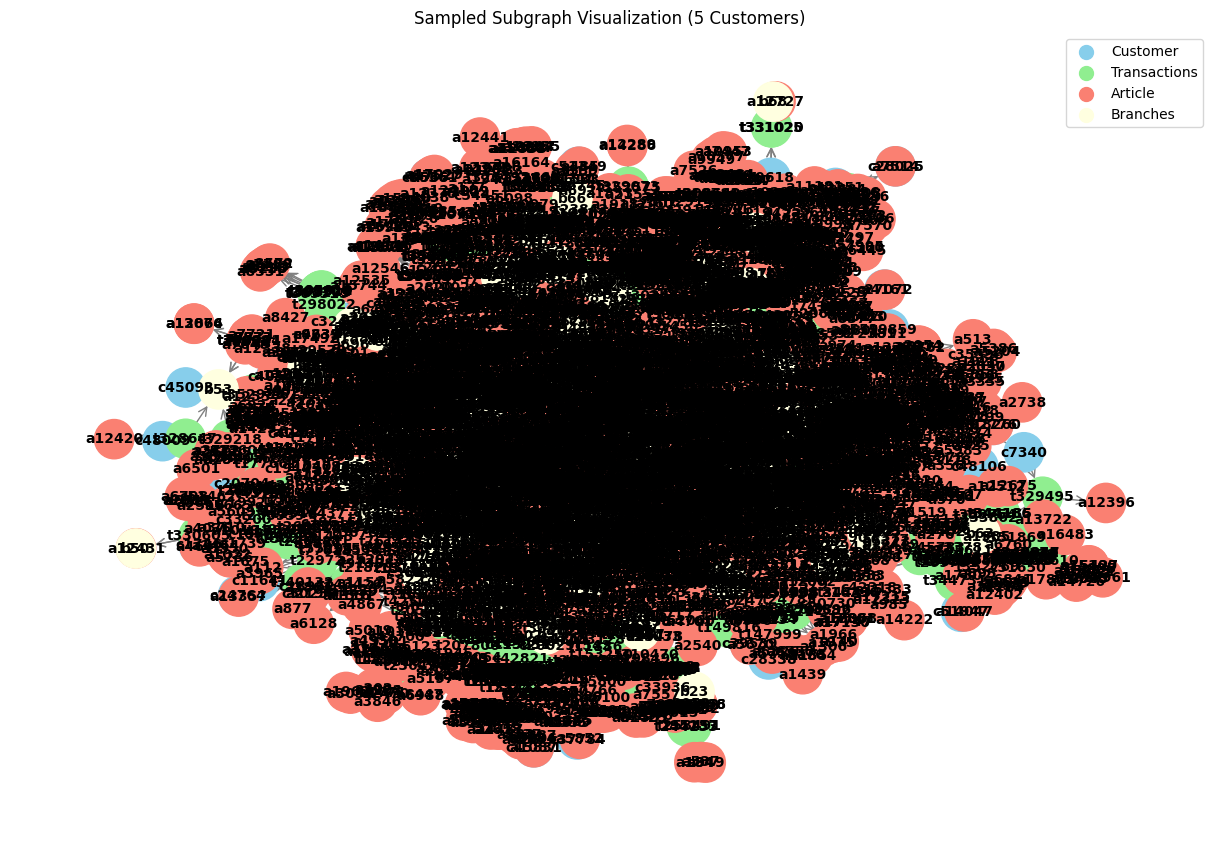

In [79]:
import networkx as nx
import matplotlib.pyplot as plt

# Convert to NetworkX (simplified)
G = nx.Graph()
for node_type in ['customer', 'transactions', 'article', 'branches']:
    for i, nid in enumerate(sampled_data[node_type].n_id):
        G.add_node(f"{node_type}_{nid}", type=node_type)

for edge_type in sampled_data.edge_types:
    edge_index = sampled_data[edge_type].edge_index
    src_type, _, dst_type = edge_type
    for src, dst in edge_index.t().tolist():
        G.add_edge(f"{src_type}_{sampled_data[src_type].n_id[src]}", f"{dst_type}_{sampled_data[dst_type].n_id[dst]}")

# Define colors and labels
node_colors = {
    'customer': 'skyblue',
    'transactions': 'lightgreen',
    'article': 'salmon',
    'branches': 'lightyellow'
}
pos = nx.spring_layout(G)
colors = [node_colors[G.nodes[n]['type']] for n in G.nodes()]
labels = {n: n.split('_')[0][0] + n.split('_')[1] for n in G.nodes()}  # e.g., "c0" for customer_0

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(
    G, 
    pos, 
    node_color=colors, 
    with_labels=True, 
    labels=labels, 
    node_size=800, 
    font_size=10, 
    font_weight='bold', 
    edge_color='gray', 
    arrows=True, 
    arrowstyle='->', 
    arrowsize=15
)

# Add a legend
for node_type, color in node_colors.items():
    plt.scatter([], [], c=color, label=node_type.capitalize(), s=100)
plt.legend(loc='upper right')

plt.title("Sampled Subgraph Visualization (5 Customers)")
plt.show()

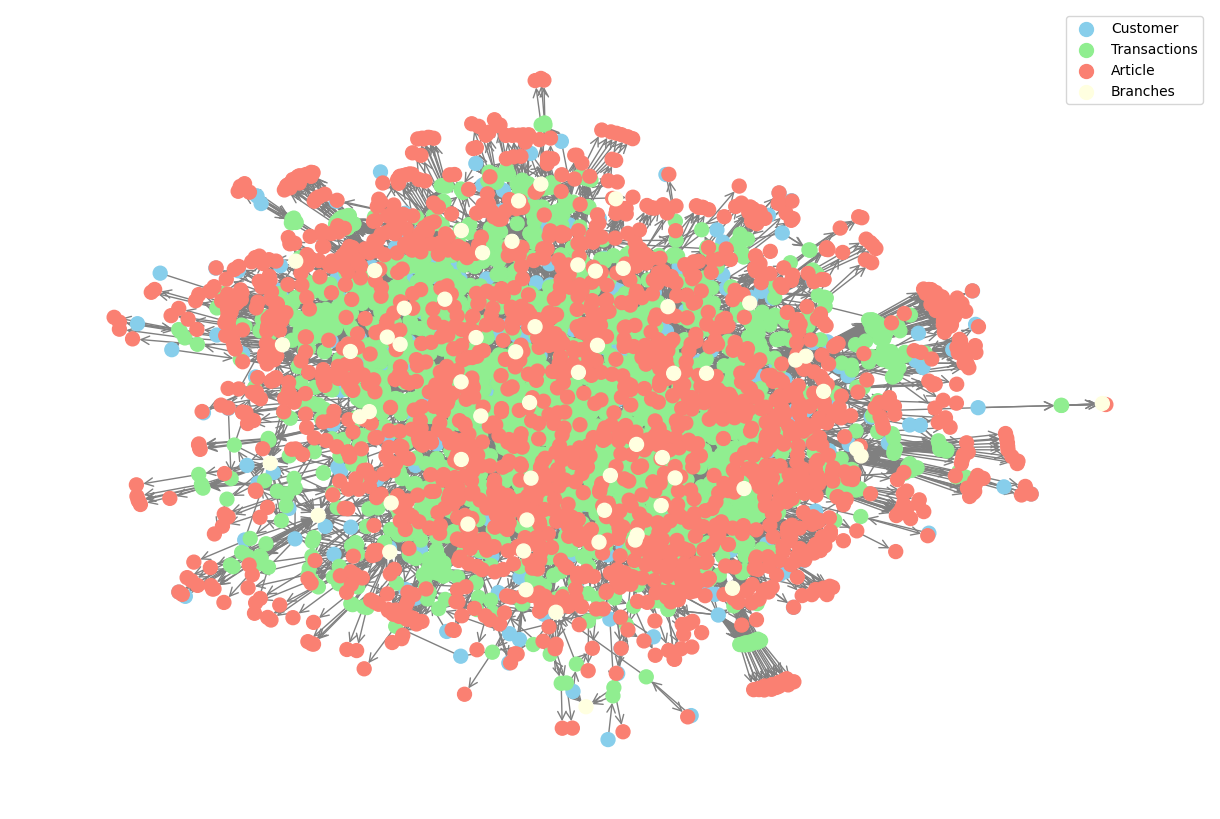

In [82]:
pos = nx.spring_layout(G)
colors = [node_colors[G.nodes[n]['type']] for n in G.nodes()]
# labels = {n: n.split('_')[0][0] + n.split('_')[1] for n in G.nodes()}  # e.g., "c0" for customer_0

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw(
    G, 
    pos, 
    node_color=colors, 
    # with_labels=True, 
    # labels=labels, 
    node_size=100, 
    font_size=5, 
    font_weight='bold', 
    edge_color='gray', 
    arrows=True, 
    arrowstyle='->', 
    arrowsize=15
)

# Add a legend
for node_type, color in node_colors.items():
    plt.scatter([], [], c=color, label=node_type.capitalize(), s=100)
plt.legend(loc='upper right')

plt.show()

In [76]:
from torch_geometric.data import HeteroData

# Assuming loader_dict["train"] is your NeighborLoader for the training set
loader_iter = iter(loader_dict["train"])

# Iterate over all mini-batches
for batch_idx, sampled_data in enumerate(loader_iter):
    print(f"Batch {batch_idx + 1}:")
    print(sampled_data)
    print("-------------------")

Batch 1:
HeteroData(
  article={
    tf=TensorFrame([3350, 28]),
    n_id=[3350],
    batch=[3350],
    num_sampled_nodes=[3],
  },
  branches={
    tf=TensorFrame([1167, 2]),
    n_id=[1167],
    batch=[1167],
    num_sampled_nodes=[3],
  },
  customer={
    tf=TensorFrame([512, 3]),
    n_id=[512],
    batch=[512],
    num_sampled_nodes=[3],
    input_id=[512],
    seed_time=[512],
    batch_size=512,
    y=[512],
  },
  transactions={
    tf=TensorFrame([3583, 10]),
    time=[3583],
    n_id=[3583],
    batch=[3583],
    num_sampled_nodes=[3],
  },
  edge_index={ n_id=[0] },
  (transactions, f2p_articles_id, article)={
    edge_index=[2, 0],
    e_id=[0],
    num_sampled_edges=[2],
  },
  (article, rev_f2p_articles_id, transactions)={
    edge_index=[2, 3583],
    e_id=[3583],
    num_sampled_edges=[2],
  },
  (transactions, f2p_customers_id, customer)={
    edge_index=[2, 3583],
    e_id=[3583],
    num_sampled_edges=[2],
  },
  (customer, rev_f2p_customers_id, transactions)={
    

In [24]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 369/369 [00:46<00:00,  7.87it/s]


Epoch: 01, Train loss: 0.31442034839614424, Val metrics: {'average_precision': np.float64(0.18159012196819835), 'accuracy': 0.8930163447251115, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.5970835644296544)}


100%|██████████| 369/369 [00:44<00:00,  8.30it/s]


Epoch: 02, Train loss: 0.309099152926319, Val metrics: {'average_precision': np.float64(0.212065920186351), 'accuracy': 0.8930163447251115, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6127287853577371)}


100%|██████████| 369/369 [00:45<00:00,  8.20it/s]


...

Epoch: 08, Train loss: 0.30299683573115693, Val metrics: {'average_precision': np.float64(0.22089053500319028), 'accuracy': 0.8930163447251115, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6515991865409503)}


100%|██████████| 369/369 [00:44<00:00,  8.22it/s]


Epoch: 09, Train loss: 0.3023754780211879, Val metrics: {'average_precision': np.float64(0.23554996433119235), 'accuracy': 0.8930163447251115, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6653956369014605)}


100%|██████████| 369/369 [00:44<00:00,  8.21it/s]


Epoch: 10, Train loss: 0.3020917164380552, Val metrics: {'average_precision': np.float64(0.22453995401735885), 'accuracy': 0.8930163447251115, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6674292845257904)}
Best Val metrics: {'average_precision': np.float64(0.22889958926670836), 'accuracy': 0.8930163447251115, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6676372712146423)}
Best test metrics: {'average_precision': np.float64(0.2832459954838795), 'accuracy': 0.8498817966903073, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6334475923472014)}


In [40]:
torch.cuda.empty_cache()

In [131]:
model_save_path = "Dorsa_model1.pth"
torch.save(state_dict, model_save_path)

In [34]:
test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

Best test metrics: {'average_precision': np.float64(0.9837159759619983), 'accuracy': 0.9423314568172456, 'f1': np.float64(0.9700936354034392), 'roc_auc': np.float64(0.8070413296874958)}


In [169]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 565/565 [01:05<00:00,  8.65it/s]


Epoch: 01, Train loss: 0.2414975541133717, Val metrics: {'average_precision': np.float64(0.14849607996615885), 'accuracy': 0.9222941720629048, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6176207193007593)}


100%|██████████| 565/565 [01:04<00:00,  8.74it/s]


Epoch: 02, Train loss: 0.2369921408765474, Val metrics: {'average_precision': np.float64(0.16528940295876007), 'accuracy': 0.9222941720629048, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6314538854659215)}


100%|██████████| 565/565 [01:06<00:00,  8.52it/s]


...

Epoch: 08, Train loss: 0.2325167836109616, Val metrics: {'average_precision': np.float64(0.17409258792295015), 'accuracy': 0.9232192414431082, 'f1': np.float64(0.023529411764705882), 'roc_auc': np.float64(0.661448631609113)}


100%|██████████| 565/565 [01:05<00:00,  8.59it/s]


Epoch: 09, Train loss: 0.23241595943550375, Val metrics: {'average_precision': np.float64(0.16633807134244313), 'accuracy': 0.9222941720629048, 'f1': np.float64(0.0), 'roc_auc': np.float64(0.6603142761618188)}


100%|██████████| 565/565 [01:06<00:00,  8.55it/s]


Epoch: 10, Train loss: 0.2317596764391489, Val metrics: {'average_precision': np.float64(0.17277765111191923), 'accuracy': 0.9259944495837188, 'f1': np.float64(0.09090909090909091), 'roc_auc': np.float64(0.6634546496632756)}
Best Val metrics: {'average_precision': np.float64(0.17286922620349432), 'accuracy': 0.9259944495837188, 'f1': np.float64(0.09090909090909091), 'roc_auc': np.float64(0.6634665902469313)}
Best test metrics: {'average_precision': np.float64(0.23289829896104242), 'accuracy': 0.8960546282245827, 'f1': np.float64(0.028368794326241134), 'roc_auc': np.float64(0.6494248966297274)}


In [225]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 2387/2387 [03:56<00:00, 10.10it/s]


Epoch: 01, Train loss: 0.20502651639105604, Val metrics: {'average_precision': np.float64(0.9697697494588908), 'accuracy': 0.940374526098112, 'f1': np.float64(0.9691689273479733), 'roc_auc': np.float64(0.6942309989945782)}


100%|██████████| 2387/2387 [03:55<00:00, 10.12it/s]


Epoch: 02, Train loss: 0.2015492363208246, Val metrics: {'average_precision': np.float64(0.9707073929208436), 'accuracy': 0.9407574771186765, 'f1': np.float64(0.9693802822476891), 'roc_auc': np.float64(0.7010806150941283)}


100%|██████████| 2387/2387 [03:56<00:00, 10.11it/s]


...

Epoch: 08, Train loss: 0.1981104319960383, Val metrics: {'average_precision': np.float64(0.971665820186683), 'accuracy': 0.9418297399762571, 'f1': np.float64(0.9700175670607741), 'roc_auc': np.float64(0.7075944816477183)}


100%|██████████| 2387/2387 [03:57<00:00, 10.04it/s]


Epoch: 09, Train loss: 0.19770088957627185, Val metrics: {'average_precision': np.float64(0.9715346637783392), 'accuracy': 0.9408340673227894, 'f1': np.float64(0.9694331783559205), 'roc_auc': np.float64(0.7066477583360669)}


100%|██████████| 2387/2387 [03:50<00:00, 10.37it/s]


Epoch: 10, Train loss: 0.19737171452135396, Val metrics: {'average_precision': np.float64(0.9710037673855457), 'accuracy': 0.9414084938536361, 'f1': np.float64(0.9697616506581288), 'roc_auc': np.float64(0.7010153826870098)}
Best Val metrics: {'average_precision': np.float64(0.9716659723560541), 'accuracy': 0.94190633018037, 'f1': np.float64(0.9700558615108269), 'roc_auc': np.float64(0.707597228556113)}
Best test metrics: {'average_precision': np.float64(0.970642274989393), 'accuracy': 0.9393212974754663, 'f1': np.float64(0.9686762829189064), 'roc_auc': np.float64(0.7157368202273662)}


In [52]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

  0%|          | 0/369 [00:00<?, ?it/s]Traceback (most recent call last):
  File "c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\torch\fx\graph_module.py", line 304, in __call__
    return super(self.cls, obj).__call__(*args, **kwargs)  # type: ignore[misc]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\torch\nn\modules\module.py", line 1532, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\KN2C\miniconda3\envs\kamal\Lib\site-packages\torch\nn\modules\module.py", line 1541, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<eval_with_key>.1", line 10, in forward
    edge_index__movie__to__director = edge_index_dict.get(('movie', 'to', 'director'), None)
                                      ^^^^^^^^^^^^^^^^^^^
AttributeError: 'str' object has no attribute 'get'

Call using an F

AttributeError: 'str' object has no attribute 'get'

In [555]:
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, val_table)
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] > best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] < best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, val_table)
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

100%|██████████| 312/312 [00:37<00:00,  8.42it/s]


Epoch: 01, Train loss: 0.3036382453270213, Val metrics: {'average_precision': np.float64(0.08149909583754936), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.18506493506493507), 'roc_auc': np.float64(0.382574963304676)}


100%|██████████| 312/312 [00:36<00:00,  8.55it/s]


Epoch: 02, Train loss: 0.29769873404821234, Val metrics: {'average_precision': np.float64(0.07927084788972695), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.18506493506493507), 'roc_auc': np.float64(0.37240511637659884)}


100%|██████████| 312/312 [00:36<00:00,  8.49it/s]


...

Epoch: 18, Train loss: 0.2815974957005092, Val metrics: {'average_precision': np.float64(0.07236593788583265), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.16333333333333333), 'roc_auc': np.float64(0.3112112951701964)}


100%|██████████| 312/312 [00:36<00:00,  8.46it/s]


Epoch: 19, Train loss: 0.28002526003469314, Val metrics: {'average_precision': np.float64(0.07483377593858881), 'accuracy': 0.10554561717352415, 'f1': np.float64(0.16666666666666666), 'roc_auc': np.float64(0.331795624519466)}


100%|██████████| 312/312 [00:36<00:00,  8.57it/s]


Epoch: 20, Train loss: 0.27847757654976885, Val metrics: {'average_precision': np.float64(0.0781954544439005), 'accuracy': 0.1001788908765653, 'f1': np.float64(0.171334431630972), 'roc_auc': np.float64(0.364122457538268)}
Best Val metrics: {'average_precision': np.float64(0.08149909583754936), 'accuracy': 0.10196779964221825, 'f1': np.float64(0.18506493506493507), 'roc_auc': np.float64(0.382574963304676)}
Best test metrics: {'average_precision': np.float64(0.11981170288209966), 'accuracy': 0.14697802197802198, 'f1': np.float64(0.2562874251497006), 'roc_auc': np.float64(0.38755700031604134)}


In [170]:
test_pred = test(loader_dict["test"])

In [565]:
test_pred

array([2.2340145, 2.42365  , 2.3910878, 1.9651055, 2.635047 , 2.8125134,
       2.9141939, 2.2264369, 2.0779622, 2.3920996, 3.0969882, 2.4129744,
       3.0757098, 2.864708 , 2.5034294, 2.7289915, 2.6368017, 2.8812795,
       3.0616727, 3.026916 , 2.7588956, 3.1603408, 3.1004765, 3.018543 ,
       2.749207 , 2.0653594, 2.4637835, 3.0846555, 2.8144748, 2.2830656,
       2.3707862, 3.0710647, 2.431739 , 2.2137074, 1.8520021, 2.9022338,
       3.0094109, 1.9472306, 3.1234567, 3.0915687, 2.7333903, 2.2532468,
       3.1200771, 2.7500458, 2.7889016, 2.7099855, 2.807791 , 2.4613554,
       2.1795695, 2.4637082, 1.8362317, 2.2145002, 2.526186 , 2.8383348,
       2.7034883, 3.0142655, 2.7882974, 2.767608 , 2.2250628, 2.792282 ,
       2.7570925, 2.2517154, 2.635968 , 2.029555 , 2.903744 , 2.6759653,
       2.949788 , 2.7997477, 2.4565923, 2.020189 , 2.8271596, 2.4267097,
       2.492117 , 2.819358 , 2.5993326, 2.1765358, 1.9197769, 2.307284 ,
       2.3475156, 2.4267442, 2.7634962, 2.0826788, 

In [556]:
customer_ids = test_table.df["customers_id"].values  # Extract the customer_id column
predicted_labels = test_pred  # This contains the model's predicted labels

# Now zip customer_ids with the predictions
results = list(zip(customer_ids, predicted_labels))

# If you'd like to show or process the results, you can format them as a dataframe
results_df = pd.DataFrame(results, columns=["customers_id", "predicted_churn"])

# You can now inspect the predictions
print(results_df)

     customers_id  predicted_churn
0            1555         2.234015
1            2084         2.423650
2            2314         2.391088
3            2619         1.965106
4            2638         2.635047
..            ...              ...
723         44669         1.965225
724         46246         2.547095
725         46603         2.807388
726         47306         2.673507
727         47596         2.087492

[728 rows x 2 columns]


In [175]:
index_map_dict1 = db.reindex_pkeys_and_fkeys()
print(index_map_dict1)

{'article': articles_id
54821.0       0
53612.0       1
59459.0       2
54126.0       3
44301.0       4
           ... 
17315.0    7567
23028.0    7568
46775.0    7569
39866.0    7570
42931.0    7571
Name: index, Length: 7572, dtype: Int64, 'customer': customers_id
10121860.0         0
10447769.0         1
10469286.0         2
10075749.0         3
10432889.0         4
               ...  
10475955.0    149147
10465306.0    149148
10461949.0    149149
10477874.0    149150
10440367.0    149151
Name: index, Length: 149152, dtype: Int64, 'branches': BranchCode
10284.0     0
10124.0     1
10706.0     2
11008.0     3
10002.0     4
10100.0     5
10131.0     6
10562.0     7
11086.0     8
10593.0     9
10168.0    10
10267.0    11
10887.0    12
10008.0    13
10006.0    14
10003.0    15
10099.0    16
10656.0    17
10672.0    18
10536.0    19
10642.0    20
10594.0    21
10001.0    22
10748.0    23
10010.0    24
10113.0    25
10595.0    26
10732.0    27
11155.0    28
10803.0    29
10643.0    30
107

In [557]:
reverse_mapping = {v: k for k, v in index_map_dict1['customer'].items()}

# Map back to original customers_id
results_df['mapped_customers_id'] = results_df['customers_id'].map(reverse_mapping)

In [558]:
# Add label column based on threshold
results_df["label"] = (results_df["predicted_churn"] >= 0.5).astype(int)


In [559]:
test_data1 = task.get_table("test", mask_input_cols=False)
test1 = test_data1.df

In [560]:
reverse_mapping = {v: k for k, v in index_map_dict1['customer'].items()}

# Map back to original customers_id
test1['mapped_customers_id'] = test1['customers_id'].map(reverse_mapping)

In [561]:
test1

,timestamp,customers_id,churn,mapped_customers_id
0,2025-01-11,1555,0,10421084.0
1,2025-01-11,2084,0,10392031.0
2,2025-01-11,2314,0,10435708.0
3,2025-01-11,2619,0,10479974.0
4,2025-01-11,2638,0,10074995.0
...,...,...,...,...
723,2025-01-11,44669,1,10356557.0
724,2025-01-11,46246,0,10367110.0
725,2025-01-11,46603,0,10418557.0
726,2025-01-11,47306,0,10408668.0


In [564]:
results_df

,customers_id,predicted_churn,mapped_customers_id,label
0,1555,2.234015,10421084.0,1
1,2084,2.423650,10392031.0,1
2,2314,2.391088,10435708.0,1
3,2619,1.965106,10479974.0,1
4,2638,2.635047,10074995.0,1
...,...,...,...,...
723,44669,1.965225,10356557.0,1
724,46246,2.547095,10367110.0,1
725,46603,2.807388,10418557.0,1
726,47306,2.673507,10408668.0,1


In [337]:
results_df.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\result_dorsa4.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_16676\3450000447.py:1: SyntaxWarning: invalid escape sequence '\D'
  results_df.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\result_dorsa4.csv', index=False)


In [319]:
test1.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\test_dorsa4.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\KN2C\AppData\Local\Temp\ipykernel_16676\653013400.py:1: SyntaxWarning: invalid escape sequence '\D'
  test1.to_csv('C:\\Users\\KN2C\Desktop\\Dani\\relbench\\test_dorsa4.csv', index=False)


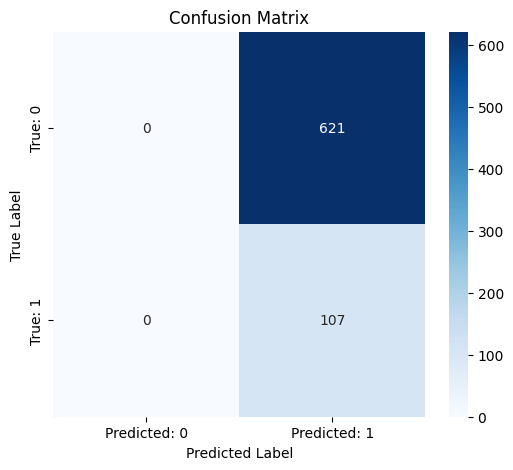

Confusion Matrix:
[[  0 621]
 [  0 107]]
ROC AUC Score: 0.5000


In [563]:
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

df_merge = pd.merge(results_df, test1, on="mapped_customers_id", how="inner")
y_pred = df_merge['label']
y_true = df_merge['churn']
# Step 1: Calculate the confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Step 2: Calculate the ROC AUC score
# For ROC AUC, we need predicted probabilities (not just labels).
# So, assuming you have probability scores, here we will simulate a model 
# using predicted labels (0 or 1) as scores for simplicity.

# If you have probabilities, you would use them like this:
# roc_auc = roc_auc_score(y_true, y_pred_probabilities)

# Here we're using the predicted label itself as the score (0 or 1)
roc_auc = roc_auc_score(y_true, y_pred)

# Step 3: Plot the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Predicted: 0", "Predicted: 1"], 
            yticklabels=["True: 0", "True: 1"])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

# Print the confusion matrix and ROC AUC score
print("Confusion Matrix:")
print(conf_matrix)
print(f"ROC AUC Score: {roc_auc:.4f}")

# GNNExplainer

In [25]:
@torch.no_grad()
def explain_with_captum(model, loader, entity_table, device):
    model.eval()
    ig = IntegratedGradients(lambda x_dict: model.forward_with_x_dict(x_dict, entity_table))

    # Extend model with a method to accept x_dict directly (for Captum)
    def forward_with_x_dict(self, x_dict):
        batch = loader.data  # Use the full data as a template
        batch.x_dict = x_dict  # Replace x_dict with the one provided by Captum
        return self(batch, entity_table)

    model.forward_with_x_dict = forward_with_x_dict.__get__(model, Model)

    # Collect a single batch for explanation (or iterate over all for full coverage)
    for batch in loader:
        batch = batch.to(device)
        input_x_dict = batch.x_dict
        target = batch[entity_table].y.float()

        # Create baseline (zeroed-out features)
        baseline_x_dict = {node_type: torch.zeros_like(x) for node_type, x in input_x_dict.items()}

        # Compute attributions
        attributions = ig.attribute(
            inputs=input_x_dict,
            baselines=baseline_x_dict,
            additional_forward_args=(entity_table,),
            target=None,  # None for all outputs; specify index for specific predictions
            n_steps=50  # Number of interpolation steps
        )

        # Print or store attributions
        print("\nCaptum Attributions for Test Batch:")
        for node_type, attr in attributions.items():
            print(f"{node_type}: Shape={attr.shape}, Mean={attr.mean().item():.4f}, Std={attr.std().item():.4f}")

        break  # Explain only one batch for simplicity; remove to process all

# Run explanation on test set
explain_with_captum(model, loader_dict["test"], task.entity_table, device)

NameError: name 'IntegratedGradients' is not defined

In [45]:
!pip install captum


   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.3 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.3 MB 2.1 MB/s eta 0:00:01
   ------------------------------- -------- 1.0/1.3 MB 2.1 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 1.8 MB/s eta 0:00:00


In [63]:
import torch
from captum.attr import IntegratedGradients
from torch_geometric.explain import CaptumExplainer

# Assuming `batch` is the HeteroData object passed from your loader
# Move to device (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch = batch.to(device)  # Move batch to device

# Step 1: Extract node features for the 'transactions' node type
# Extract the features (assuming 'tf' is the key holding the features)
node_features = batch.transactions.tf.to(device)  # Node features for transactions

# Step 2: Extract edge indices for the 'transactions' node type
edge_index_trans_to_article = batch['transactions', 'f2p_articles_id', 'article'].edge_index.to(device)
edge_index_trans_to_customer = batch['transactions', 'f2p_customers_id', 'customer'].edge_index.to(device)
edge_index_trans_to_branches = batch['transactions', 'f2p_BranchCode', 'branches'].edge_index.to(device)

# Now you have node features for transactions and edge indices connecting transactions to articles, customers, and branches

# Example of selecting a target for attribution: Let's say we want to explain the prediction for the first 'transaction'
target = model(batch, task.entity_table)  # Get the model's output (prediction for each node)
target = target.view(-1) if target.size(1) == 1 else target  # Flatten if needed

# Initialize IntegratedGradients
ig = IntegratedGradients(model)

# For example, let's explain the prediction for the first 'transaction' (index 0)
index = 0

# Step 3: Use CaptumExplainer to compute attributions
captum_explainer = CaptumExplainer('IntegratedGradients')

# Compute the attributions for the first 'transaction'
attributions, delta = captum_explainer.forward(
    model=model,
    x=node_features,
    edge_index=edge_index_trans_to_article,  # Use appropriate edge index
    target=target,
    index=index,
)

# Print out the attributions and convergence delta
print("Attributions: ", attributions)
print("Delta: ", delta)


AttributeError: 'HeteroData' has no attribute 'transactions'

In [133]:
data1 = data

In [134]:
data1['transactions'].tf

TensorFrame(
  num_cols=10,
  num_rows=357020,
  categorical (2): ['Season', 'Transaction Type'],
  numerical (6): ['Discount Percentage', 'Quantity', 'Sale Total Price', 'Style Code', 'Total Discounts', 'Transaction Serial'],
  timestamp (2): ['Time', 'datetime'],
  has_target=False,
  device='cpu',
)

In [72]:
data.edge_index_dict

{('transactions',
  'f2p_articles_id',
  'article'): tensor([[     0,      1,      2,  ..., 357017, 357018, 357019],
         [     0,      1,      2,  ...,  18255,  12902,  12319]]),
 ('article',
  'rev_f2p_articles_id',
  'transactions'): tensor([[     0,      0,      0,  ...,  18253,  18254,  18255],
         [     0,    340,   2337,  ..., 357015, 357016, 357017]]),
 ('transactions',
  'f2p_customers_id',
  'customer'): tensor([[     0,      1,      2,  ..., 357017, 357018, 357019],
         [     0,      1,      2,  ...,  48904,  54954,  43350]]),
 ('customer',
  'rev_f2p_customers_id',
  'transactions'): tensor([[     0,      0,      0,  ...,  54954,  54954,  54954],
         [     0,    192,    626,  ..., 357005, 357013, 357018]]),
 ('transactions',
  'f2p_BranchCode',
  'branches'): tensor([[     0,      1,      2,  ..., 357017, 357018, 357019],
         [     0,      1,      2,  ...,     54,     59,     65]]),
 ('branches',
  'rev_f2p_BranchCode',
  'transactions'): tensor([[  

In [135]:
data1.keys

<bound method BaseData.keys of HeteroData(
  article={ tf=TensorFrame([18258, 28]) },
  branches={ tf=TensorFrame([75, 2]) },
  customer={ tf=TensorFrame([54955, 3]) },
  transactions={
    tf=TensorFrame([357020, 10]),
    time=[357020],
  },
  (transactions, f2p_articles_id, article)={ edge_index=[2, 357020] },
  (article, rev_f2p_articles_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_customers_id, customer)={ edge_index=[2, 357020] },
  (customer, rev_f2p_customers_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_BranchCode, branches)={ edge_index=[2, 357020] },
  (branches, rev_f2p_BranchCode, transactions)={ edge_index=[2, 357020] }
)>

In [136]:
data1

HeteroData(
  article={ tf=TensorFrame([18258, 28]) },
  branches={ tf=TensorFrame([75, 2]) },
  customer={ tf=TensorFrame([54955, 3]) },
  transactions={
    tf=TensorFrame([357020, 10]),
    time=[357020],
  },
  (transactions, f2p_articles_id, article)={ edge_index=[2, 357020] },
  (article, rev_f2p_articles_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_customers_id, customer)={ edge_index=[2, 357020] },
  (customer, rev_f2p_customers_id, transactions)={ edge_index=[2, 357020] },
  (transactions, f2p_BranchCode, branches)={ edge_index=[2, 357020] },
  (branches, rev_f2p_BranchCode, transactions)={ edge_index=[2, 357020] }
)

In [140]:
customer_features = data1['article'].tf

In [74]:
customer_features = data['customer'].tf

In [141]:
customer_features.col_names_dict

{<stype.numerical: 'numerical'>: ['Base Unit Price'],
 <stype.categorical: 'categorical'>: ['Brand',
  'Collection Code',
  'Idea Code',
  'Initial Pattern Code',
  'Product Category',
  'Season',
  'Style Code',
  'Year'],
 <stype.embedding: 'embedding'>: ['Article Description',
  'Collection Name',
  'Color',
  'Combined Feature',
  'Dimensions',
  'Idea Description',
  'Initial Pattern Description',
  'Material Category',
  'Material Type',
  'Model',
  'Processing',
  'Product Group',
  'Product Subgroup',
  'Product Type',
  'Size',
  'Style Description',
  'Usage Space',
  'Usage Type',
  'User']}

In [142]:
# Access the feature dictionary
for stype, tensor in customer_features.feat_dict.items():
    print(f"\nFeature type: {stype}")
    print(f"Tensor shape: {tensor.shape}")
    print(f"Sample data (first 5 rows):\n{tensor[:5]}")


Feature type: numerical
Tensor shape: torch.Size([18258, 1])
Sample data (first 5 rows):
tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

Feature type: categorical
Tensor shape: torch.Size([18258, 8])
Sample data (first 5 rows):
tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

Feature type: embedding
Tensor shape: (18258, 19, -1)
Sample data (first 5 rows):
MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')


In [99]:
customer_features.feat_dict

{<stype.categorical: 'categorical'>: tensor([[3, 0],
         [0, 0],
         [0, 0],
         ...,
         [0, 0],
         [0, 0],
         [8, 0]]),
 <stype.embedding: 'embedding'>: MultiEmbeddingTensor(num_rows=54955, num_cols=1, device='cpu')}

In [103]:
print("Keys in feat_dict:", list(customer_features.feat_dict.keys()))

# Iterate again to confirm
for stype, tensor in customer_features.feat_dict.items():
    print(f"\nFeature type: {stype}")
    print(f"Tensor shape: {tensor.shape}")
    print(f"Sample data (first 5 rows):\n{tensor[:]}")

Keys in feat_dict: [<stype.categorical: 'categorical'>, <stype.embedding: 'embedding'>]

Feature type: categorical
Tensor shape: torch.Size([54955, 2])
Sample data (first 5 rows):
tensor([[3, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [8, 0]])

Feature type: embedding
Tensor shape: (54955, 1, -1)
Sample data (first 5 rows):
MultiEmbeddingTensor(num_rows=54955, num_cols=1, device='cpu')


In [104]:
import torch_frame

# Using stype key
cat_tensor = customer_features.feat_dict[torch_frame.stype.categorical]
print("Categorical tensor shape:", cat_tensor.shape)
print("Sample (first 5 rows):\n", cat_tensor[:5])
# Full tensor (be cautious with large output)
print("Full categorical tensor:\n", cat_tensor)
# Save to file to avoid console overload
torch.save(cat_tensor, 'categorical_tensor.pt')
print("Saved categorical tensor to 'categorical_tensor.pt'")

Categorical tensor shape: torch.Size([54955, 2])
Sample (first 5 rows):
 tensor([[3, 0],
        [0, 0],
        [0, 0],
        [0, 0],
        [0, 0]])
Full categorical tensor:
 tensor([[3, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [8, 0]])
Saved categorical tensor to 'categorical_tensor.pt'


In [108]:
cat_tensor

tensor([[3, 0],
        [0, 0],
        [0, 0],
        ...,
        [0, 0],
        [0, 0],
        [8, 0]])

In [107]:
emb_tensor = customer_features.feat_dict[torch_frame.stype.embedding]
emb_dict = emb_tensor.to_dict()
print("Embedding dictionary:", emb_dict)
# If it contains a tensor, extract it
if isinstance(emb_dict, dict) and 'values' in emb_dict:
    values_tensor = emb_dict['values']
    print("Values tensor shape:", values_tensor.shape)
    print("Sample (first 5 rows):\n", values_tensor[:5])
    torch.save(values_tensor, 'embedding_values.pt')
    print("Saved embedding values to 'embedding_values.pt'")

Embedding dictionary: {'num_rows': 54955, 'num_cols': 1, 'values': tensor([[-0.3551,  0.5848,  0.4965,  ...,  0.3306, -0.4648, -0.2486],
        [ 0.2203, -0.1769,  0.9615,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.2203, -0.1769,  0.9615,  ..., -0.2600,  0.0966, -0.0193],
        ...,
        [ 0.0234, -0.3570,  0.6478,  ..., -0.2222, -0.2385,  0.5443],
        [-0.3551,  0.5848,  0.4965,  ...,  0.3306, -0.4648, -0.2485],
        [ 0.0234, -0.3570,  0.6478,  ..., -0.2222, -0.2385,  0.5443]]), 'offset': tensor([  0, 768])}
Values tensor shape: torch.Size([54955, 768])
Sample (first 5 rows):
 tensor([[-0.3551,  0.5848,  0.4965,  ...,  0.3306, -0.4648, -0.2486],
        [ 0.2203, -0.1769,  0.9615,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.2203, -0.1769,  0.9615,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.5988, -0.1003,  0.6091,  ...,  1.1986, -0.4069,  0.1680],
        [ 0.2203, -0.1769,  0.9615,  ..., -0.2600,  0.0966, -0.0193]])
Saved embedding values to 'embedding_values.pt'

In [111]:
import torch
import torch_frame

# Get both tensors
cat_tensor = customer_features.feat_dict[torch_frame.stype.categorical]
emb_tensor = customer_features.feat_dict[torch_frame.stype.embedding]

# Use to_dict() to get embedding data
emb_dict = emb_tensor.to_dict()
print("Embedding dictionary:", emb_dict)  # Inspect the dictionary

# Extract the tensor (assuming 'values' key holds the embeddings)
if isinstance(emb_dict, dict) and 'values' in emb_dict:
    emb_values = emb_dict['values']
else:
    raise ValueError("Could not find 'values' in emb_dict. Check emb_dict contents.")

# Squeeze if it has an extra dimension (e.g., [54955, 1, D] -> [54955, D])
if len(emb_values.shape) == 3:
    emb_values = emb_values.squeeze(1)

# Concatenate
combined_tensor = torch.cat([cat_tensor, emb_values], dim=1)
print("Combined tensor shape:", combined_tensor.shape)
print("Sample (first 5 rows):\n", combined_tensor[:5])
torch.save(combined_tensor, 'combined_customer_tensor.pt')
print("Saved combined tensor to 'combined_customer_tensor.pt'")

Embedding dictionary: {'num_rows': 54955, 'num_cols': 1, 'values': tensor([[-0.3551,  0.5848,  0.4965,  ...,  0.3306, -0.4648, -0.2486],
        [ 0.2203, -0.1769,  0.9615,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.2203, -0.1769,  0.9615,  ..., -0.2600,  0.0966, -0.0193],
        ...,
        [ 0.0234, -0.3570,  0.6478,  ..., -0.2222, -0.2385,  0.5443],
        [-0.3551,  0.5848,  0.4965,  ...,  0.3306, -0.4648, -0.2485],
        [ 0.0234, -0.3570,  0.6478,  ..., -0.2222, -0.2385,  0.5443]]), 'offset': tensor([  0, 768])}
Combined tensor shape: torch.Size([54955, 770])
Sample (first 5 rows):
 tensor([[ 3.0000,  0.0000, -0.3551,  ...,  0.3306, -0.4648, -0.2486],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.0000,  0.0000,  0.5988,  ...,  1.1986, -0.4069,  0.1680],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193]])
Saved combined tensor to 'combined_customer_t

In [113]:
# Create x_dict-like structure for customer
my_x_dict = {
    'customer': combined_tensor
}
print("My x_dict-like structure:", my_x_dict)
print("Customer tensor shape:", my_x_dict['customer'].shape)
print("Sample (first 5 rows):\n", my_x_dict['customer'][:5])

My x_dict-like structure: {'customer': tensor([[ 3.0000,  0.0000, -0.3551,  ...,  0.3306, -0.4648, -0.2486],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193],
        ...,
        [ 0.0000,  0.0000,  0.0234,  ..., -0.2222, -0.2385,  0.5443],
        [ 0.0000,  0.0000, -0.3551,  ...,  0.3306, -0.4648, -0.2485],
        [ 8.0000,  0.0000,  0.0234,  ..., -0.2222, -0.2385,  0.5443]])}
Customer tensor shape: torch.Size([54955, 770])
Sample (first 5 rows):
 tensor([[ 3.0000,  0.0000, -0.3551,  ...,  0.3306, -0.4648, -0.2486],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193],
        [ 0.0000,  0.0000,  0.5988,  ...,  1.1986, -0.4069,  0.1680],
        [ 0.0000,  0.0000,  0.2203,  ..., -0.2600,  0.0966, -0.0193]])


In [143]:
import torch
import torch_frame

# Initialize a list to collect tensors
tensors = []

# Iterate over all stype keys in feat_dict
for stype, tensor in customer_features.feat_dict.items():
    print(f"\nProcessing feature type: {stype}")
    print(f"Tensor shape: {tensor.shape}")
    print(f"Sample (first 5 rows):\n", tensor[:5])

    # Handle different tensor types
    if isinstance(tensor, torch_frame.data.multi_embedding_tensor.MultiEmbeddingTensor):
        # For MultiEmbeddingTensor (e.g., embedding)
        emb_dict = tensor.to_dict()
        print("Embedding dictionary:", emb_dict)
        if isinstance(emb_dict, dict) and 'values' in emb_dict:
            processed_tensor = emb_dict['values']
        else:
            raise ValueError(f"Could not find 'values' in emb_dict for {stype}. Check emb_dict contents.")
        # Squeeze if it has an extra dimension (e.g., [N, 1, D] -> [N, D])
        if len(processed_tensor.shape) == 3:
            processed_tensor = processed_tensor.squeeze(1)
    else:
        # For standard tensors (e.g., categorical)
        processed_tensor = tensor

    tensors.append(processed_tensor)

# Concatenate all tensors
if tensors:
    combined_tensor = torch.cat(tensors, dim=1)
    print("Combined tensor shape:", combined_tensor.shape)
    print("Sample (first 5 rows):\n", combined_tensor[:5])
    torch.save(combined_tensor, 'combined_customer_tensor.pt')
    print("Saved combined tensor to 'combined_customer_tensor.pt'")
else:
    print("No tensors found to concatenate.")


Processing feature type: numerical
Tensor shape: torch.Size([18258, 1])
Sample (first 5 rows):
 tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

Processing feature type: categorical
Tensor shape: torch.Size([18258, 8])
Sample (first 5 rows):
 tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

Processing feature type: embedding
Tensor shape: (18258, 19, -1)
Sample (first 5 rows):
 MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')
Embedding dictionary: {'num_rows': 18258, 'num_cols': 19, 'values': tensor([[ 0.0393, -1.5238,  1.0980,  ...,  0.1530, -1.0556,  0.3658],
        [-0.2922, -0.8280,  0.8872,  ...,  1.0870, -0.8658, -0.8590],
        [ 0.5265, -0.8788,  0.6881,  ...,  1.0870, -0.8658, -0.8590],
        ...,
 

In [146]:
tf = data['article'].tf

In [148]:
tf.feat_dict.items()

dict_items([(<stype.numerical: 'numerical'>, tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        ...,
        [1.9361e+09],
        [1.9551e+09],
        [2.1903e+09]])), (<stype.categorical: 'categorical'>, tensor([[   0,    0,    0,  ...,    1,  266,    5],
        [   0,    0,    0,  ...,    0,  977,    5],
        [   0,    0,    0,  ...,    3,  307,    6],
        ...,
        [   1,    5,    0,  ...,    0,  152,    5],
        [   1,    5,    0,  ...,    0,  152,    5],
        [   1,    5,    1,  ...,    0, 1746,    4]])), (<stype.embedding: 'embedding'>, MultiEmbeddingTensor(num_rows=18258, num_cols=19, device='cpu'))])

In [149]:
for stype, tensor in tf.feat_dict.items():
    print(f"\n  Processing feature type: {stype}")
    print(f"  Tensor shape: {tensor.shape}")
    print(f"  Sample (first 5 rows):\n", tensor[:5])

    # Handle different tensor types
    if isinstance(tensor, torch_frame.data.multi_embedding_tensor.MultiEmbeddingTensor):
        # For MultiEmbeddingTensor (e.g., embedding)
        emb_dict = tensor.to_dict()
        print(f"  Embedding dictionary:", emb_dict)
        if isinstance(emb_dict, dict) and 'values' in emb_dict:
            processed_tensor = emb_dict['values']
        else:
            raise ValueError(f"Could not find 'values' in emb_dict for {stype}. Check emb_dict contents.")
        # Squeeze if it has an extra dimension (e.g., [N, 1, D] -> [N, D])
        if len(processed_tensor.shape) == 3:
            processed_tensor = processed_tensor.squeeze(1)
    else:
        # For standard tensors (e.g., categorical)
        processed_tensor = tensor

    tensors.append(processed_tensor)


  Processing feature type: numerical
  Tensor shape: torch.Size([18258, 1])
  Sample (first 5 rows):
 tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

  Processing feature type: categorical
  Tensor shape: torch.Size([18258, 8])
  Sample (first 5 rows):
 tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

  Processing feature type: embedding
  Tensor shape: (18258, 19, -1)
  Sample (first 5 rows):
 MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')
  Embedding dictionary: {'num_rows': 18258, 'num_cols': 19, 'values': tensor([[ 0.0393, -1.5238,  1.0980,  ...,  0.1530, -1.0556,  0.3658],
        [-0.2922, -0.8280,  0.8872,  ...,  1.0870, -0.8658, -0.8590],
        [ 0.5265, -0.8788,  0.6881,  ...,  1.0870, -0.8658, -0.8

In [151]:
node_type = 'article'
x_dict = {}

In [152]:
if tensors:
    combined_tensor = torch.cat(tensors, dim=1)
    x_dict[node_type] = combined_tensor  # Store in x_dict
    print(f"  Combined tensor shape:", combined_tensor.shape)
    print(f"  Sample (first 5 rows):\n", combined_tensor[:5])
    torch.save(combined_tensor, f'combined_{node_type}_tensor.pt')
    print(f"  Saved combined tensor to 'combined_{node_type}_tensor.pt'")
else:
    print(f"  No tensors found to concatenate for {node_type}")

  Combined tensor shape: torch.Size([18258, 29202])
  Sample (first 5 rows):
 tensor([[ 1.1743e+08,  0.0000e+00,  0.0000e+00,  ...,  1.5301e-01,
         -1.0556e+00,  3.6576e-01],
        [ 8.8743e+07,  0.0000e+00,  0.0000e+00,  ...,  1.0870e+00,
         -8.6583e-01, -8.5902e-01],
        [ 1.0409e+08,  0.0000e+00,  0.0000e+00,  ...,  1.0870e+00,
         -8.6583e-01, -8.5902e-01],
        [ 4.5000e+07,  0.0000e+00,  8.0000e+00,  ...,  1.5301e-01,
         -1.0556e+00,  3.6576e-01],
        [ 5.5000e+07,  0.0000e+00,  0.0000e+00,  ...,  1.0870e+00,
         -8.6583e-01, -8.5902e-01]])
  Saved combined tensor to 'combined_article_tensor.pt'


In [154]:
import torch
import torch_frame
from torch_geometric.data import HeteroData

# Assuming 'data' is your HeteroData object
# If not defined, replace with your actual data loading (e.g., data = torch.load('your_data.pt'))

# Dictionary to store combined tensors for each node type (like x_dict)
x_dict = {}

# List of node types from your HeteroData
node_types = ['article', 'branches', 'customer', 'transactions']

# Loop over all node types
for node_type in node_types:
    print(f"\nProcessing node type: {node_type}")
    if node_type in node_types:
        # Get the TensorFrame for this node type
        tf = data[node_type].tf
        tensors = []  # Initialize a list to collect tensors

        # Iterate over all stype keys in feat_dict
        for stype, tensor in tf.feat_dict.items():
            print(f"\n  Processing feature type: {stype}")
            print(f"  Tensor shape: {tensor.shape}")
            print(f"  Sample (first 5 rows):\n", tensor[:5])

            # Handle different tensor types
            if isinstance(tensor, torch_frame.data.multi_embedding_tensor.MultiEmbeddingTensor):
                # For MultiEmbeddingTensor (e.g., embedding)
                emb_dict = tensor.to_dict()
                print(f"  Embedding dictionary:", emb_dict)
                if isinstance(emb_dict, dict) and 'values' in emb_dict:
                    processed_tensor = emb_dict['values']
                else:
                    raise ValueError(f"Could not find 'values' in emb_dict for {stype}. Check emb_dict contents.")
                # Squeeze if it has an extra dimension (e.g., [N, 1, D] -> [N, D])
                if len(processed_tensor.shape) == 3:
                    processed_tensor = processed_tensor.squeeze(1)
            else:
                # For standard tensors (e.g., categorical)
                processed_tensor = tensor

            tensors.append(processed_tensor)

        # Concatenate all tensors for this node type
        if tensors:
            combined_tensor = torch.cat(tensors, dim=1)
            x_dict[node_type] = combined_tensor  # Store in x_dict
            print(f"  Combined tensor shape:", combined_tensor.shape)
            print(f"  Sample (first 5 rows):\n", combined_tensor[:5])
            torch.save(combined_tensor, f'combined_{node_type}_tensor.pt')
            print(f"  Saved combined tensor to 'combined_{node_type}_tensor.pt'")
        else:
            print(f"  No tensors found to concatenate for {node_type}")
    else:
        print(f"  Node type {node_type} not found in data.")

# Final x_dict-like structure
print("\nFull x_dict-like structure:", {k: v.shape for k, v in x_dict.items()})


Processing node type: article

  Processing feature type: numerical
  Tensor shape: torch.Size([18258, 1])
  Sample (first 5 rows):
 tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

  Processing feature type: categorical
  Tensor shape: torch.Size([18258, 8])
  Sample (first 5 rows):
 tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

  Processing feature type: embedding
  Tensor shape: (18258, 19, -1)
  Sample (first 5 rows):
 MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')
  Embedding dictionary: {'num_rows': 18258, 'num_cols': 19, 'values': tensor([[ 0.0393, -1.5238,  1.0980,  ...,  0.1530, -1.0556,  0.3658],
        [-0.2922, -0.8280,  0.8872,  ...,  1.0870, -0.8658, -0.8590],
        [ 0.5265, -0.8788,  0.688

RuntimeError: Tensors must have same number of dimensions: got 2 and 3

In [155]:
import torch
import torch_frame
from torch_geometric.data import HeteroData

# Assuming 'data' is your HeteroData object
# Dictionary to store combined tensors for each node type (like x_dict)
x_dict = {}

# List of node types from your HeteroData
node_types = ['article', 'branches', 'customer', 'transactions']

# Process each node type
for node_type in node_types:
    print(f"\nProcessing node type: {node_type}")
    if node_type in node_types:
        tf = data[node_type].tf  # Access TensorFrame
        tensors = []  # Initialize a list to collect tensors

        # Iterate over all stype keys in feat_dict
        for stype, tensor in tf.feat_dict.items():
            print(f"\n  Processing feature type: {stype}")
            print(f"  Tensor shape: {tensor.shape}")
            print(f"  Sample (first 5 rows):\n", tensor[:5])

            # Handle different tensor types
            if isinstance(tensor, torch_frame.data.multi_embedding_tensor.MultiEmbeddingTensor):
                # For MultiEmbeddingTensor (e.g., embedding)
                emb_dict = tensor.to_dict()
                print(f"  Embedding dictionary:", emb_dict)
                if isinstance(emb_dict, dict) and 'values' in emb_dict:
                    processed_tensor = emb_dict['values']
                else:
                    raise ValueError(f"Could not find 'values' in emb_dict for {stype}. Check emb_dict contents.")
                # Squeeze if it has an extra dimension (e.g., [N, 1, D] -> [N, D])
                if len(processed_tensor.shape) == 3:
                    processed_tensor = processed_tensor.squeeze(1)
            else:
                # For standard tensors (e.g., categorical, numerical, timestamp)
                processed_tensor = tensor
                # Flatten if tensor is 3D (e.g., timestamp [N, 2, 7] -> [N, 14])
                if len(processed_tensor.shape) == 3:
                    processed_tensor = processed_tensor.view(processed_tensor.shape[0], -1)

            tensors.append(processed_tensor)

        # Concatenate all tensors for this node type
        if tensors:
            combined_tensor = torch.cat(tensors, dim=1)
            x_dict[node_type] = combined_tensor  # Store in x_dict
            print(f"  Combined tensor shape:", combined_tensor.shape)
            print(f"  Sample (first 5 rows):\n", combined_tensor[:5])
            torch.save(combined_tensor, f'combined_{node_type}_tensor.pt')
            print(f"  Saved combined tensor to 'combined_{node_type}_tensor.pt'")
        else:
            print(f"  No tensors found to concatenate for {node_type}")
    else:
        print(f"  Node type {node_type} not found in data.")

# Final x_dict-like structure
print("\nFull x_dict-like structure:", {k: v.shape for k, v in x_dict.items()})


Processing node type: article

  Processing feature type: numerical
  Tensor shape: torch.Size([18258, 1])
  Sample (first 5 rows):
 tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

  Processing feature type: categorical
  Tensor shape: torch.Size([18258, 8])
  Sample (first 5 rows):
 tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

  Processing feature type: embedding
  Tensor shape: (18258, 19, -1)
  Sample (first 5 rows):
 MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')
  Embedding dictionary: {'num_rows': 18258, 'num_cols': 19, 'values': tensor([[ 0.0393, -1.5238,  1.0980,  ...,  0.1530, -1.0556,  0.3658],
        [-0.2922, -0.8280,  0.8872,  ...,  1.0870, -0.8658, -0.8590],
        [ 0.5265, -0.8788,  0.688

In [156]:
x_dict

{'article': tensor([[ 1.1743e+08,  0.0000e+00,  0.0000e+00,  ...,  1.5301e-01,
          -1.0556e+00,  3.6576e-01],
         [ 8.8743e+07,  0.0000e+00,  0.0000e+00,  ...,  1.0870e+00,
          -8.6583e-01, -8.5902e-01],
         [ 1.0409e+08,  0.0000e+00,  0.0000e+00,  ...,  1.0870e+00,
          -8.6583e-01, -8.5902e-01],
         ...,
         [ 1.9361e+09,  1.0000e+00,  5.0000e+00,  ..., -7.1060e-01,
          -1.2736e+00, -1.3546e+00],
         [ 1.9551e+09,  1.0000e+00,  5.0000e+00,  ..., -7.1060e-01,
          -1.2736e+00, -1.3546e+00],
         [ 2.1903e+09,  1.0000e+00,  5.0000e+00,  ...,  1.0870e+00,
          -8.6583e-01, -8.5902e-01]]),
 'branches': tensor([[ 0.2825,  0.6999,  0.8870,  ...,  0.3908,  0.6106,  0.2198],
         [ 1.0366,  0.6590,  0.9351,  ...,  0.1265, -0.1278,  0.3879],
         [-0.3163,  0.4402,  0.2276,  ...,  0.1265, -0.1278,  0.3879],
         ...,
         [ 0.7320,  0.8134,  0.9724,  ..., -0.0121,  0.3332,  0.1212],
         [ 0.1661,  0.5721,  1.21

In [167]:
import torch
import torch_frame
from torch_geometric.data import HeteroData

# Assuming 'data' is your original HeteroData object
# If not in scope, reload it (e.g., data = torch.load('your_data.pt'))

# Dictionary to store combined tensors for each node type
x_dict = {}

# List of node types from your HeteroData
node_types = ['article', 'branches', 'customer', 'transactions']

# Process each node type
for node_type in node_types:
    print(f"\nProcessing node type: {node_type}")
    if node_type in node_types:
        tf = data[node_type].tf  # Access TensorFrame
        tensors = []  # Initialize a list to collect tensors

        # Iterate over all stype keys in feat_dict
        for stype, tensor in tf.feat_dict.items():
            print(f"\n  Processing feature type: {stype}")
            print(f"  Tensor shape: {tensor.shape}")
            print(f"  Sample (first 5 rows):\n", tensor[:5])

            # Handle different tensor types
            if isinstance(tensor, torch_frame.data.multi_embedding_tensor.MultiEmbeddingTensor):
                # For MultiEmbeddingTensor (e.g., embedding)
                emb_dict = tensor.to_dict()
                print(f"  Embedding dictionary:", emb_dict)
                if isinstance(emb_dict, dict) and 'values' in emb_dict:
                    processed_tensor = emb_dict['values']
                else:
                    raise ValueError(f"Could not find 'values' in emb_dict for {stype}. Check emb_dict contents.")
                # Squeeze if it has an extra dimension (e.g., [N, 1, D] -> [N, D])
                if len(processed_tensor.shape) == 3:
                    processed_tensor = processed_tensor.squeeze(1)
            else:
                # For standard tensors (e.g., categorical, numerical, timestamp)
                processed_tensor = tensor
                # Flatten if tensor is 3D (e.g., timestamp [N, 2, 7] -> [N, 14])
                if len(processed_tensor.shape) == 3:
                    processed_tensor = processed_tensor.view(processed_tensor.shape[0], -1)

            tensors.append(processed_tensor)

        # Concatenate all tensors for this node type
        if tensors:
            combined_tensor = torch.cat(tensors, dim=1)
            x_dict[node_type] = combined_tensor  # Store in x_dict
            print(f"  Combined tensor shape:", combined_tensor.shape)
            print(f"  Sample (first 5 rows):\n", combined_tensor[:5])
        else:
            print(f"  No tensors found to concatenate for {node_type}")
    else:
        print(f"  Node type {node_type} not found in data.")

# Assign the combined tensors to data.x_dict
data.x_dict = x_dict

# Verify the result
print("\nUpdated HeteroData with x_dict:")
print(data)
print("x_dict contents:", {k: v.shape for k, v in data.x_dict.items()})


Processing node type: article

  Processing feature type: numerical
  Tensor shape: torch.Size([18258, 1])
  Sample (first 5 rows):
 tensor([[1.1743e+08],
        [8.8743e+07],
        [1.0409e+08],
        [4.5000e+07],
        [5.5000e+07]])

  Processing feature type: categorical
  Tensor shape: torch.Size([18258, 8])
  Sample (first 5 rows):
 tensor([[  0,   0,   0,  36,   0,   1, 266,   5],
        [  0,   0,   0, 330,   0,   0, 977,   5],
        [  0,   0,   0,  88,   0,   3, 307,   6],
        [  0,   8,   0,  92,   0,   0, 643,   5],
        [  0,   0,   0,  26,   0,   1, 184,   1]])

  Processing feature type: embedding
  Tensor shape: (18258, 19, -1)
  Sample (first 5 rows):
 MultiEmbeddingTensor(num_rows=5, num_cols=19, device='cpu')
  Embedding dictionary: {'num_rows': 18258, 'num_cols': 19, 'values': tensor([[ 0.0393, -1.5238,  1.0980,  ...,  0.1530, -1.0556,  0.3658],
        [-0.2922, -0.8280,  0.8872,  ...,  1.0870, -0.8658, -0.8590],
        [ 0.5265, -0.8788,  0.688

In [169]:
from torch_geometric.nn import to_hetero, SAGEConv
import torch.nn.functional as F

class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        self.conv1 = SAGEConv((-1, -1), hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.lin = torch.nn.Linear(hidden_channels, 1)  # Output a single score per node

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        return self.lin(x).squeeze(-1)  # Ensure output shape is scalar


In [170]:
# Instantiate model
model = GNN(hidden_channels=32)

# Convert to heterogeneous model
metadata = data.metadata()
model = to_hetero(model, metadata, aggr='mean')

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [186]:
data['customer']

{'tf': TensorFrame(
  num_cols=3,
  num_rows=54955,
  categorical (2): ['City', 'Customer Category'],
  embedding (1): ['Customer Process'],
  has_target=False,
  device='cpu',
), 'y': tensor([0.4671, 0.7722, 0.3908,  ..., 0.8065, 0.2462, 0.2872])}

In [1]:
batch

NameError: name 'batch' is not defined

In [190]:
import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader

# Assuming 'data' is your HeteroData with x_dict and y for customer
# Assuming 'model' and 'optimizer' are defined (e.g., from previous setup)

# Create DataLoader with the full dataset
loader = DataLoader([data], batch_size=1, shuffle=True)

# Training loop
model.train()
for epoch in range(40):
    for batch in loader:
        optimizer.zero_grad()

        # Get model predictions
        out = model(batch.x_dict, batch.edge_index_dict)  # Adjusted based on model output

        # Use 'customer' predictions for loss
        target = batch['customer'].y.float()  # Convert target to float for regression

        loss = F.mse_loss(out, target)  # Mean Squared Error loss for regression
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

: 

In [189]:
from torch_geometric.loader import DataLoader

loader = DataLoader([data], batch_size=1, shuffle=True)

# Training loop
model.train()
for epoch in range(40):
    for batch in loader:
        optimizer.zero_grad()

        # Get model predictions
        out_dict = model(batch.x_dict, batch.edge_index_dict)

        # Use 'movie' predictions for loss
        out = out_dict['movie']
        target = batch['movie'].y.float()  # Convert target to float for regression

        loss = F.mse_loss(out, target)  # Use Mean Squared Error loss
        loss.backward()
        optimizer.step()

    print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')


RuntimeError: [enforce fail at alloc_cpu.cpp:114] data. DefaultCPUAllocator: not enough memory: you tried to allocate 20851396080 bytes.

In [160]:
import torch.nn as nn
from torch_geometric.explain import Explainer, CaptumExplainer

# Wrap the model in a PyTorch Module to allow proper attribute access
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x_dict, edge_index_dict):
        """Extracts predictions for 'movie' nodes."""
        out_dict = self.model(x_dict, edge_index_dict)
        return out_dict['customer']  # Only return 'movie' node predictions

# Instantiate the wrapped model
wrapped_model = ModelWrapper(model)

# Ensure gradient tracking
for key in x_dict:
    x_dict[key].requires_grad_()

# Define the explainer with the wrapped model
explainer = Explainer(
    model=wrapped_model,  # Now passes a proper PyTorch model
    algorithm=CaptumExplainer('IntegratedGradients'),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='regression',  # FIX: Ensure explainer is in regression mode
        task_level='node',
        return_type='raw',  # Model returns raw outputs (not probabilities)
    ),
)

# Generate explanations
# Generate explanations with corrected indexing
hetero_explanation = explainer(
    x_dict,  # Node features
    data.edge_index_dict,  # Edge indices
    index=torch.tensor([1, 3])  # FIXED: Use a tensor, not a dictionary
)


# Print explanation results
print("Edge Mask Dictionary:", hetero_explanation.edge_mask_dict)
print("Node Mask Dictionary:", hetero_explanation.node_mask_dict)


TypeError: unhashable type: 'dict'

In [101]:
print("customer_features:", customer_features)
print("col_names_dict:", customer_features.col_names_dict)

customer_features: TensorFrame(
  num_cols=3,
  num_rows=54955,
  categorical (2): ['City', 'Customer Category'],
  embedding (1): ['Customer Process'],
  has_target=False,
  device='cpu',
)
col_names_dict: {<stype.categorical: 'categorical'>: ['City', 'Customer Category'], <stype.embedding: 'embedding'>: ['Customer Process']}


In [98]:
cat_tensor = customer_features.feat_dict['categorical']
print("Categorical tensor shape:", cat_tensor.shape)
print("All categorical values:\n", cat_tensor)  # Full 54955 x 2 tensor

KeyError: 'categorical'

In [91]:
print("Keys in data:", list(data.keys()))
for node_type in ['article', 'branches', 'customer', 'transactions']:
    if node_type in data:
        print(f"{node_type} attributes:", list(data[node_type].keys()))

Keys in data: ['edge_index', 'time', 'tf']


In [88]:
print("Column names by type:", customer_features.col_names_dict)

Column names by type: {<stype.categorical: 'categorical'>: ['City', 'Customer Category'], <stype.embedding: 'embedding'>: ['Customer Process']}


In [80]:
print(customer_features.feat_dict.keys()) 

dict_keys([<stype.categorical: 'categorical'>, <stype.embedding: 'embedding'>])


In [82]:
city_data = customer_features.feat_dict['categorical']

KeyError: 'categorical'

In [71]:
data.x_dict

KeyError: "Tried to collect 'x' but did not find any occurrences of it in any node and/or edge type"

In [68]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.loader import NeighborLoader

# Step 1: Define a simple GCN model (for demonstration)
class GCN(torch.nn.Module):
    def __init__(self, in_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, 16)
        self.conv2 = GCNConv(16, out_channels)

    def forward(self, data):
        # Forward function expects a Data object
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# Step 2: Create a Data object (with x, edge_index, and y attributes)
dataset = Data(
    x=torch.rand(100, 28),  # 100 nodes, 28 features each
    edge_index=torch.randint(0, 100, (2, 200)),  # 200 edges
    y=torch.randint(0, 2, (100,))  # Binary labels for nodes
)  # Replace with your actual dataset loading code

# Step 3: Initialize the model and move it to the appropriate device (GPU/CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(in_channels=28, out_channels=2)  # Assuming 28 features per node, and 2 output classes
model.to(device)

# Step 4: Train the model (simplified training loop for demonstration)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    loss_accum = count_accum = 0
    optimizer.zero_grad()
    # Pass the Data object (not just the features)
    output = model(dataset.to(device))  # Pass dataset as Data object
    loss = loss_fn(output, dataset.y.to(device))
    loss.backward()
    optimizer.step()

    loss_accum += loss.item() * dataset.num_nodes
    count_accum += dataset.num_nodes

    return loss_accum / count_accum

# Training for a few epochs
for epoch in range(10):  # Adjust the number of epochs
    train_loss = train()
    print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}")

# Step 5: Explain the prediction using Captum (Integrated Gradients)
# Let's assume we want to explain the prediction for the first node in the dataset

# Prepare the Integrated Gradients
ig = IntegratedGradients(model)

# Choose the node you want to explain (for example, the first node)
node_index = 0  # Node index to explain

# Extract the feature matrix of the node type (assuming 'x' holds features)
input_features = dataset.x.to(device)  # Features of all nodes
target = dataset.y[node_index].to(device)  # Target label for the node

# Perform Integrated Gradients Attribution
attributions, delta = ig.attribute(input_features, target=target.item(), return_convergence_delta=True)

# Step 6: Visualize the attribution scores
attributions = attributions.detach().cpu().numpy()

# Plot the attribution for the node's features
plt.bar(range(len(attributions)), attributions[0])  # Assuming the first node
plt.xlabel('Feature Index')
plt.ylabel('Attribution Score')
plt.title(f'Attribution for Node {node_index}')
plt.show()

# Optionally, print the convergence delta (how well the method converged)
print("Convergence delta:", delta)


Epoch 1, Loss: 0.9130
Epoch 2, Loss: 0.7806
Epoch 3, Loss: 0.7010
Epoch 4, Loss: 0.6814
Epoch 5, Loss: 0.7112
Epoch 6, Loss: 0.7264
Epoch 7, Loss: 0.7189
Epoch 8, Loss: 0.7032
Epoch 9, Loss: 0.6888
Epoch 10, Loss: 0.6808


AttributeError: 'Tensor' object has no attribute 'x'

In [70]:
dataset.x

AttributeError: 'TransactionalDataset' object has no attribute 'x'

In [75]:
from torch_geometric.data import HeteroData
from torch_geometric.explain import Explainer, CaptumExplainer

import torch
from torch_geometric.data import HeteroData

# Create a sample heterogeneous graph
data = HeteroData()

# Node types and features
data['author'].x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float)  # 2 authors, each with 2 features
data['paper'].x = torch.tensor([[5, 6], [7, 8]], dtype=torch.float)   # 2 papers, each with 2 features
data['institution'].x = torch.tensor([[9, 10]], dtype=torch.float)    # 1 institution, with 2 features

# Edge types
data['author', 'writes', 'paper'].edge_index = torch.tensor([[0, 1], [0, 1]], dtype=torch.long)  # author 0 writes paper 0, and author 1 writes paper 1
data['author', 'affiliated', 'institution'].edge_index = torch.tensor([[0, 1], [0, 0]], dtype=torch.long)  # author 0 and 1 are affiliated with institution 0

# Optional: Add target labels for each node
data['author'].y = torch.tensor([0, 1], dtype=torch.long)  # 2 authors with class labels 0 and 1
data['paper'].y = torch.tensor([1, 0], dtype=torch.long)   # 2 papers with class labels 1 and 0

# Print to see the data
print(data)


explainer = Explainer(
    model,  # It is assumed that model outputs a single tensor.
    algorithm=CaptumExplainer('IntegratedGradients'),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config = dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='probs',  # Model returns probabilities.
    ),
)

# Generate batch-wise heterogeneous explanations for
# the nodes at index `1` and `3`:
hetero_explanation = explainer(
    data.x_dict,
    data.edge_index_dict,
    index=torch.tensor([1, 3]),
)
print(hetero_explanation.edge_mask_dict)
print(hetero_explanation.node_mask_dict)

HeteroData(
  author={
    x=[2, 2],
    y=[2],
  },
  paper={
    x=[2, 2],
    y=[2],
  },
  institution={ x=[1, 2] },
  (author, writes, paper)={ edge_index=[2, 2] },
  (author, affiliated, institution)={ edge_index=[2, 2] }
)


TypeError: GCN.forward() takes 2 positional arguments but 3 were given